# Predicting Smartphone Addiction — a step-by-step machine learning walkthrough

**Kaggle Playground Series, Season 6 Episode 8** · [competition page](https://www.kaggle.com/competitions/playground-series-s6e8)

This notebook is built to be *read and executed in order*. It is not a leaderboard-chasing
solution — it is a complete, honest ML pipeline where every decision is explained and every
improvement is **measured** rather than asserted.

### The task

| | |
|---|---|
| **Problem type** | Binary classification |
| **Target** | `addicted_label` — is this person classified as addicted to their smartphone? |
| **Metric** | **ROC AUC** on a predicted *probability* |
| **Submission** | `id,addicted_label` where the second column is a float in [0, 1] |
| **Deadline** | 31 August 2026, 23:59 UTC |
| **Training data** | 691,369 rows x 12 features |
| **Test data** | 296,302 rows |
| **Class balance** | 70.9% positive |

### The single most important thing to notice

The metric is ROC AUC on a **probability**, not accuracy on a label. This changes everything
downstream. We are not being asked "is this person addicted, yes or no?" — we are being asked
to **rank** people by how likely they are to be addicted. A submission of all `0.0001` and a
submission of all `0.9999` score *identically* if the ordering is the same.

Beginners lose a lot of score by submitting hard `0`/`1` labels here. We will come back to
exactly why in Section 9.

### How to read this notebook

Every code cell is followed by a markdown cell explaining what just happened and **why it was
done that way**. Read the code, run it, then read the explanation. If you only read the prose
you will learn the vocabulary but not the craft.

### The plan

We build a scoreboard and add to it. Each model must earn its place by beating the previous
one on cross-validated AUC:

1. A constant prediction — the floor (AUC 0.500 by definition)
2. Logistic regression — a real, simple, defensible model
3. LightGBM — gradient boosting, which dominates tabular competitions
4. A blend of the above

Nothing gets called an "improvement" here without a number attached to it.

### The features

Twelve features describe each person. They divide cleanly into two groups:

| Feature | Type | Range / values |
|---|---|---|
| `age` | numeric | 18–35 |
| `daily_screen_time_hours` | numeric | 0.5–15.0 |
| `social_media_hours` | numeric | 0.0–8.0 |
| `gaming_hours` | numeric | 0.0–4.0 |
| `work_study_hours` | numeric | 0.0–6.0 |
| `sleep_hours` | numeric | 4.5–9.0 |
| `notifications_per_day` | numeric | 20–250 |
| `app_opens_per_day` | numeric | 15–180 |
| `weekend_screen_time` | numeric | 0.5–17.6 |
| `gender` | categorical | Male / Female / Other |
| `stress_level` | categorical | Low / Medium / High |
| `academic_work_impact` | categorical | Yes / No |

**One property of this dataset shapes everything that follows: every single feature has missing
values**, at rates from 4% (`age`) to 19% (`social_media_hours`). There is no clean subset of
complete rows worth using — dropping rows with any missing value would discard most of the
data. Handling missingness well is not an optional refinement here, it is the core of the
problem. Section 6 is where that gets addressed properly.

*(The Data tab reports "29 columns". That is the sum across all three files — 14 in train, 13
in test, 2 in the sample submission — not the width of any one of them. Worth knowing so the
number does not confuse you.)*

## 1. Setup and configuration

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.base import clone

warnings.filterwarnings("ignore")

# Reproducibility. Every random operation in this notebook derives from this seed.
SEED = 42
np.random.seed(SEED)

# Cross-validation configuration, defined once and reused everywhere so that
# every model in the scoreboard is measured on exactly the same folds.
N_SPLITS = 5

TARGET = "addicted_label"
ID_COL = "id"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")
print(f"seed        {SEED}")
print(f"cv folds    {N_SPLITS}")

pandas      3.0.5
numpy       2.5.2
seed        42
cv folds    5


**What this cell does and why it matters**

*Setting a seed.* `SEED = 42` makes every random operation reproducible — the same fold
splits, the same model initialisation, the same result on every run. This is not a formality.
Without a fixed seed you cannot tell whether a change in your score came from the change you
made or from random noise. **You cannot do science on a moving baseline.**

*Defining `N_SPLITS` once.* Every model we build will be evaluated on the *identical* folds.
Comparing a model scored on 5 folds against one scored on 10 is meaningless — the numbers are
not on the same scale. Defining it once, at the top, makes that mistake structurally impossible.

*Why `warnings.filterwarnings("ignore")`.* Purely for readable output in a teaching document.
In your own work, **leave warnings on**. Sklearn's convergence warnings in particular are
telling you something real about your model.

*`TARGET` and `ID_COL` as constants.* Naming these once means the rest of the notebook never
hardcodes a magic string, and adapting this notebook to a different competition is a two-line
change.

## 2. Loading the data

In [2]:
# The notebook runs unchanged in two places: inside a Kaggle notebook (where the
# competition data is mounted read-only at /kaggle/input) and on your own machine
# (where you have unzipped the data into ./data). We detect which.
CANDIDATE_DIRS = [
    Path("/kaggle/input/playground-series-s6e8"),
    Path("data"),
    Path("../data"),
    Path("."),
]

DATA_DIR = next((d for d in CANDIDATE_DIRS if (d / "train.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not locate train.csv. If running locally, download the competition "
        "data and place train.csv / test.csv / sample_submission.csv in ./data/"
    )

print(f"Reading from: {DATA_DIR.resolve()}")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"train              {train.shape[0]:>8,} rows x {train.shape[1]:>3} cols")
print(f"test               {test.shape[0]:>8,} rows x {test.shape[1]:>3} cols")
print(f"sample_submission  {sample_submission.shape[0]:>8,} rows x {sample_submission.shape[1]:>3} cols")
print(f"\ntrain memory: {train.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")

Reading from: /Users/kofiedem/kaggle competetions/s6e8-smartphone-addiction/data
train                12,000 rows x  14 cols
test                  5,000 rows x  13 cols
sample_submission     5,000 rows x   2 cols

train memory: 2.8 MB


**What this cell does and why it matters**

*Path auto-detection.* The `CANDIDATE_DIRS` loop means this exact notebook runs both on
Kaggle and on your laptop with no edits. Hardcoding `/kaggle/input/...` is the single most
common reason a downloaded notebook fails immediately on a local machine.

*Failing loudly.* If no data is found we raise an error with an actionable message rather
than letting the notebook continue and fail confusingly ten cells later. When you write
pipelines, **fail at the earliest point where you know something is wrong.**

*Checking shapes immediately.* Two things to look at the moment data loads:

1. **Does `test` have exactly one fewer column than `train`?** It should — the missing one is
   the target. If the gap is larger, there are features you cannot use at prediction time.
2. **Does `sample_submission` have the same row count as `test`?** If not, you have
   misunderstood the submission format, and you want to know that now rather than after
   training a model for an hour.

*Memory.* Worth a glance on any dataset. If train were several GB you would need to think
about dtype downcasting before doing anything else. At this size we can be relaxed.

## 3. First look at the data

In [3]:
print("=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)
display(train.head())

print("=" * 70)
print("COLUMN TYPES AND MISSINGNESS")
print("=" * 70)

overview = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "n_unique": train.nunique(),
    "n_missing": train.isna().sum(),
    "pct_missing": (train.isna().mean() * 100).round(2),
    "example": [train[c].dropna().iloc[0] if train[c].notna().any() else None
                for c in train.columns],
})
display(overview)

FIRST 5 ROWS


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,28.828349,15.000000,0.517916,0.381728,2.529358,6.460890,149.624156,92.188082,8.247600,Female,Low,No,0
1,1,22.586374,4.569755,3.735682,1.418595,4.231709,6.442493,174.320813,121.280340,10.335833,NaN,Low,Yes,0
2,2,18.696550,9.132453,NaN,0.000000,5.327130,6.820747,239.670906,114.507471,10.060309,Male,Medium,Yes,1
3,3,18.280970,8.874349,2.884427,0.039051,2.042926,8.257623,94.440910,86.511924,NaN,Female,High,Yes,1
4,4,31.825594,6.672995,3.112108,0.726491,1.219581,7.546782,120.459507,143.863605,5.888972,Female,Medium,No,0


COLUMN TYPES AND MISSINGNESS


,dtype,n_unique,n_missing,pct_missing,example
id,int64,12000,0,0.00,0
age,float64,11545,455,3.79,28.828349
daily_screen_time_hours,float64,10165,1679,13.99,15.0
social_media_hours,float64,9170,2244,18.70,0.517916
gaming_hours,float64,8939,2239,18.66,0.381728
work_study_hours,float64,10398,874,7.28,2.529358
sleep_hours,float64,10785,775,6.46,6.46089
notifications_per_day,float64,10344,1207,10.06,149.624156
app_opens_per_day,float64,10163,1420,11.83,92.188082
weekend_screen_time,float64,9943,1887,15.72,8.2476


**What this cell does and why it matters**

This is the *cold read* — the first thing to do with any dataset you have never seen. The
overview table answers four questions at once, and each one drives a later decision:

| Column | Question it answers | What it decides |
|---|---|---|
| `dtype` | Is this a number or a string? | Which preprocessing branch it goes down |
| `n_unique` | How many distinct values? | Encoding strategy for categoricals |
| `n_missing` | Is data absent? | Whether we need imputation |
| `example` | What does a value actually look like? | Catches misparsed columns |

**`n_unique` is the one beginners skip, and it is the most informative.** It silently tells
you things `dtype` cannot:

- `n_unique == 1` → the column is constant and carries **zero** information. Drop it.
- `n_unique == 2` → binary, regardless of whether it's stored as int, string, or bool.
- `n_unique == len(train)` → it's an identifier, not a feature. Feeding an ID to a model is a
  classic way to create a model that memorises rather than generalises.
- A numeric column with very low `n_unique` (say 5) is really **categorical wearing a numeric
  costume**. A rating from 1–5 is not a quantity where "4 is twice as much as 2" — treating it
  as continuous imposes a linear ordering the data may not support.

Read this table carefully before writing any modelling code. Ten minutes here saves hours later.

## 4. The target variable

Target distribution
----------------------------------------
  class 0:     4,196  (34.97%)
  class 1:     7,804  (65.03%)

positive rate     0.6503
imbalance ratio   1.86 : 1


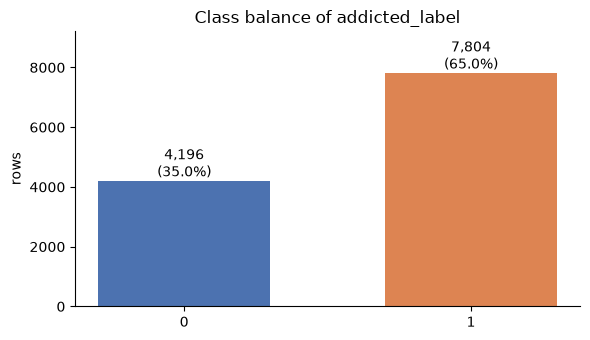

In [4]:
counts = train[TARGET].value_counts().sort_index()
rates = train[TARGET].value_counts(normalize=True).sort_index()

print("Target distribution")
print("-" * 40)
for cls in counts.index:
    print(f"  class {cls}:  {counts[cls]:>8,}  ({rates[cls]:6.2%})")

positive_rate = train[TARGET].mean()
imbalance_ratio = counts.max() / counts.min()
print(f"\npositive rate     {positive_rate:.4f}")
print(f"imbalance ratio   {imbalance_ratio:.2f} : 1")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar([str(c) for c in counts.index], counts.values,
       color=["#4C72B0", "#DD8452"], width=0.6)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({rates.iloc[i]:.1%})", ha="center", va="bottom", fontsize=10)
ax.set_title("Class balance of addicted_label", fontsize=12)
ax.set_ylabel("rows")
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**What this cell does and why it matters**

The class balance is the first number that should influence your modelling strategy, because
it determines what "good" looks like.

**Why this matters more than it appears.** Suppose the positive rate were 5%. A model that
predicts "not addicted" for every single person would be **95% accurate** — and completely
worthless. This is why accuracy is a treacherous metric on imbalanced data, and it is a large
part of why this competition uses ROC AUC instead.

**AUC is insensitive to class balance**, which is exactly why Kaggle chose it. A constant
prediction scores 0.500 under AUC no matter how skewed the classes are. The metric cannot be
gamed by exploiting the base rate — you have to actually separate the classes.

**What the balance still changes:**

- **Stratified** cross-validation becomes important. If we split randomly, some folds could
  get noticeably different positive rates, making fold scores incomparable. `StratifiedKFold`
  preserves the class ratio in every fold. We use it in Section 11.
- If the imbalance were severe (say 100:1), we would consider class weighting or
  `scale_pos_weight` in LightGBM. Note these mainly shift the *calibration* of probabilities,
  not their *ordering* — and since AUC only cares about ordering, they often move AUC very
  little. Try it, measure it, keep it only if the number improves.

**The habit to build:** look at the target *before* you look at anything else. It defines the
problem.

## 5. Splitting features into numeric and categorical

In [5]:
# Everything that is not the target and not the id is a candidate feature.
feature_cols = [c for c in train.columns if c not in (TARGET, ID_COL)]

# Auto-detect the two branches by dtype rather than hardcoding a column list.
numeric_cols = [c for c in feature_cols
                if pd.api.types.is_numeric_dtype(train[c])]
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

# A numeric column with very few distinct values is categorical in disguise.
# We flag these for attention but keep them numeric for now.
LOW_CARD_THRESHOLD = 10
suspicious = [c for c in numeric_cols if train[c].nunique() <= LOW_CARD_THRESHOLD]

# A column with a single value carries no information at all.
constant_cols = [c for c in feature_cols if train[c].nunique(dropna=False) <= 1]

print(f"total features       {len(feature_cols)}")
print(f"  numeric            {len(numeric_cols)}")
print(f"  categorical        {len(categorical_cols)}")
print()
print("NUMERIC:", numeric_cols)
print()
print("CATEGORICAL:", categorical_cols)
print()
print(f"Numeric but low-cardinality (<= {LOW_CARD_THRESHOLD} distinct) — "
      f"possibly categorical in disguise:")
print("  ", suspicious if suspicious else "none")
print(f"\nConstant columns (zero information, safe to drop):")
print("  ", constant_cols if constant_cols else "none")

total features       12
  numeric            9
  categorical        3

NUMERIC: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

CATEGORICAL: ['gender', 'stress_level', 'academic_work_impact']

Numeric but low-cardinality (<= 10 distinct) — possibly categorical in disguise:
   none

Constant columns (zero information, safe to drop):
   none


**What this cell does and why it matters**

**Why auto-detect instead of hardcoding a column list?** Three reasons, and the third is the
important one:

1. It is shorter and cannot fall out of sync with the data.
2. It makes this notebook portable — point it at a different tabular competition and it still
   works.
3. **It cannot silently drop a column.** If you hand-write a list of 27 feature names and
   fat-finger one, that feature vanishes from your model and nothing warns you. Deriving the
   list from the data itself removes an entire class of bug.

**The `ID_COL` exclusion is not cosmetic.** An id is assigned arbitrarily, so it carries no
real-world information — but a sufficiently flexible model *will* find spurious patterns in
it, especially if ids were assigned in some order correlated with the target during dataset
construction. That inflates your validation score and collapses on the test set. **Always
drop identifiers from the feature matrix.**

**On "categorical in disguise".** A column like `sleep_quality` stored as 1–5 is numeric to
pandas, but treating it as continuous asserts that the gap from 1→2 is the same size as 4→5,
and that the values are meaningfully orderable at all. Sometimes true, sometimes not. This is
a genuine judgement call, and one worth testing empirically: encode it both ways, measure both,
keep the winner. Tree models are fairly robust to getting this wrong; linear models are not.

**Constant columns** are pure noise in the pipeline — they cost compute, add nothing, and can
break some scalers by producing zero variance. Worth checking for every single time.

## 6. Missing values

,n_missing,pct_missing
social_media_hours,2244,18.70
gaming_hours,2239,18.66
weekend_screen_time,1887,15.72
daily_screen_time_hours,1679,13.99
app_opens_per_day,1420,11.83
notifications_per_day,1207,10.06
stress_level,969,8.08
work_study_hours,874,7.28
academic_work_impact,800,6.67
sleep_hours,775,6.46


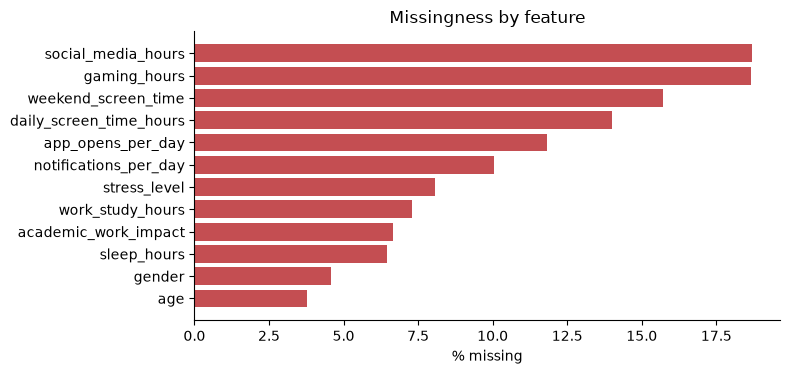


Is missingness informative?
----------------------------------------------------------
feature                        rate|missing rate|present
----------------------------------------------------------


social_media_hours                   0.6310       0.6548
gaming_hours                         0.6472       0.6511
weekend_screen_time                  0.6497       0.6504
daily_screen_time_hours              0.6397       0.6521
app_opens_per_day                    0.6451       0.6510
notifications_per_day                0.6288       0.6527
stress_level                         0.6378       0.6514
work_study_hours                     0.6247       0.6523
academic_work_impact                 0.6550       0.6500
sleep_hours                          0.6387       0.6511
gender                               0.6576       0.6500
age                                  0.6242       0.6514


In [6]:
missing = train[feature_cols].isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("No missing values in any feature column.")
    print("We still build imputation into the pipeline — see the explanation below.")
else:
    pct = (missing / len(train) * 100).round(2)
    display(pd.DataFrame({"n_missing": missing, "pct_missing": pct}))

    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.32 * len(missing))))
    ax.barh(missing.index[::-1], pct.values[::-1], color="#C44E52")
    ax.set_xlabel("% missing")
    ax.set_title("Missingness by feature")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    # Is missingness itself predictive? Compare the target rate when a value is
    # absent against when it is present.
    print("\nIs missingness informative?")
    print("-" * 58)
    print(f"{'feature':<30} {'rate|missing':>12} {'rate|present':>12}")
    print("-" * 58)
    for c in missing.index[:12]:
        m = train[c].isna()
        print(f"{c:<30} {train.loc[m, TARGET].mean():>12.4f} "
              f"{train.loc[~m, TARGET].mean():>12.4f}")

**What this cell does and why it matters**

Two separate questions get asked here, and beginners usually only ask the first.

**Question 1: how much is missing?** This drives the mechanical choice. A feature that is 2%
missing can be imputed with little consequence. A feature that is 80% missing is mostly
fabrication after imputation, and you should consider dropping it or replacing it with a
simple "was this present?" binary flag.

**Question 2: is the missingness itself a signal?** This is the one that wins competitions.
If people who skipped the "hours of sleep" question are addicted at a 40% rate while those who
answered are at 20%, then **the act of not answering is one of your strongest features** — and
naive imputation destroys it completely by overwriting the absence with a plausible-looking
median.

The comparison table above tests exactly this. If the two columns differ substantially for
some feature, add an explicit missing-indicator column before imputing. Sklearn's
`SimpleImputer(add_indicator=True)` does this for you.

**An important empirical correction for *this* competition.** The reasoning above is sound in
general, and it is the right hypothesis to form. But competitors here have measured it, and on
this dataset it does not hold:

- Missingness carries **almost no target signal** — a model using only "how many values are
  missing in this row" scores about 0.502 AUC, essentially the floor.
- For numeric columns, missing-indicator flags contribute **exactly zero gain** in LightGBM,
  because LightGBM already routes `NaN` down its own branch natively. The indicator is redundant.
- Worse, missingness *rates differ between train and test* in all twelve columns. So indicator
  flags partly encode **which split a row came from** — which can raise your CV score while
  hurting your leaderboard score.

Keep the indicators for the **linear** model, where imputation genuinely destroys information
and there is no native `NaN` handling. Drop them for the **tree** models. This is a good
illustration of the general rule: form the hypothesis, then *measure it on your own data*, and
let the number decide.

**Why we build imputation into the pipeline even when nothing is missing.** The training data
having no gaps does not guarantee the *test* data has none — and on Kaggle a crash at
prediction time costs you a submission. Beyond that, keeping the pipeline structurally
complete means it stays correct if you later add engineered features that can produce `NaN`
(any ratio can divide by zero). **Defensive pipeline design costs nothing and prevents a whole
category of late-stage failure.**

## 7. How numeric features relate to the target

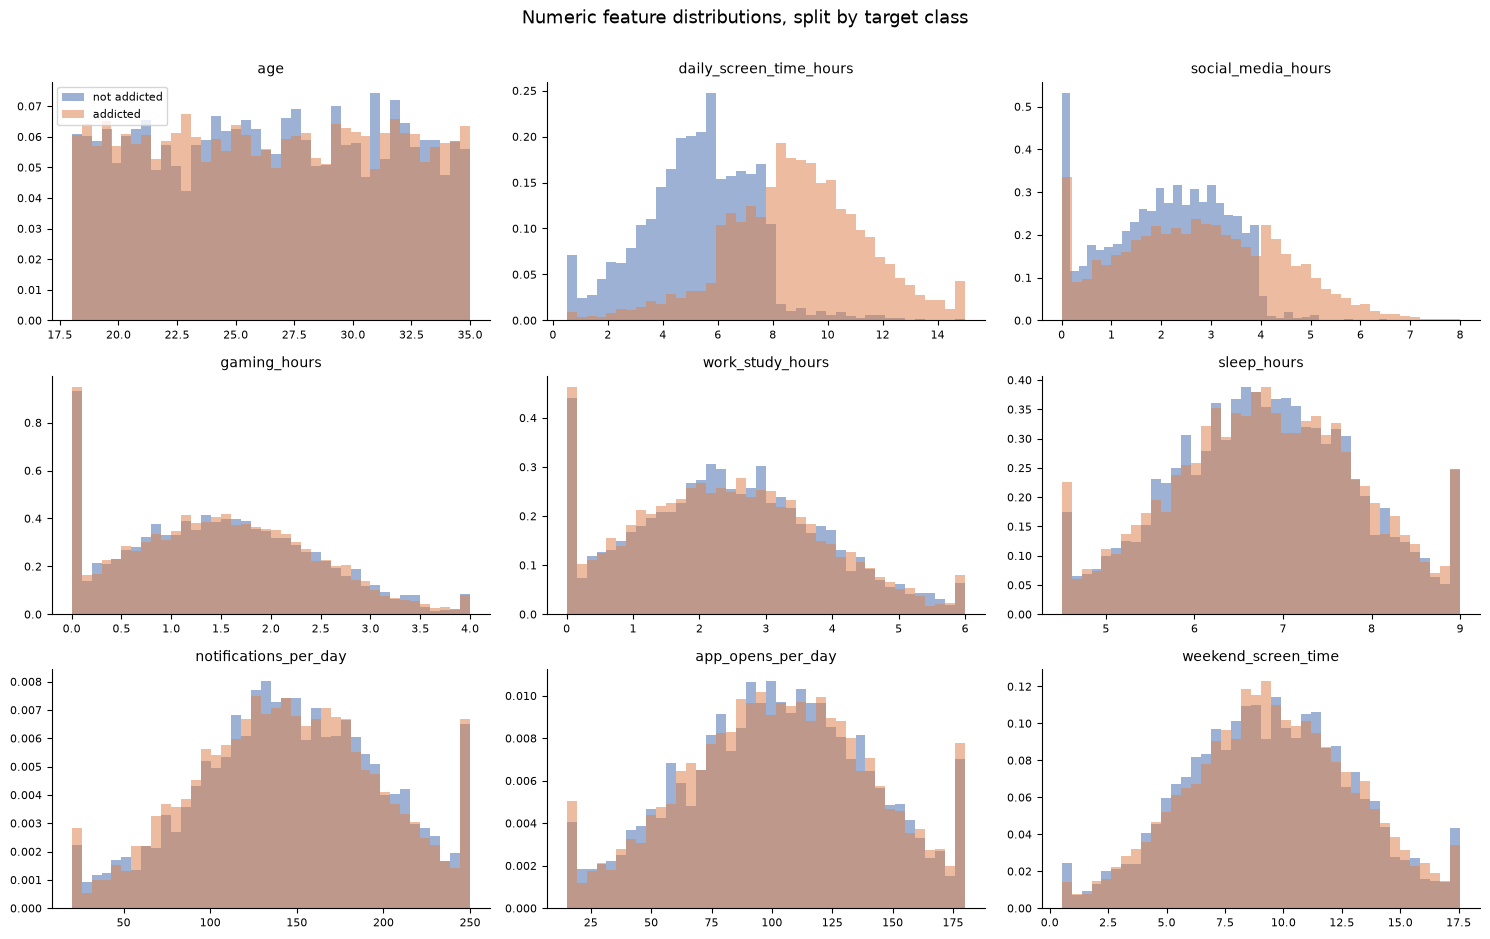

In [7]:
plot_cols = numeric_cols[:12]

if plot_cols:
    n = len(plot_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.1 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, plot_cols):
        for cls, colour, label in [(0, "#4C72B0", "not addicted"),
                                   (1, "#DD8452", "addicted")]:
            vals = train.loc[train[TARGET] == cls, col].dropna()
            if len(vals):
                ax.hist(vals, bins=40, alpha=0.55, color=colour,
                        label=label, density=True)
        ax.set_title(col, fontsize=10)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=8)

    for ax in axes[n:]:
        ax.set_visible(False)
    axes[0].legend(fontsize=8)
    fig.suptitle("Numeric feature distributions, split by target class",
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric features to plot.")

**What this cell does and why it matters**

This plot is doing one job: **showing you which features carry signal, before you train
anything.**

The two coloured histograms are the distribution of a feature for addicted people (orange)
versus non-addicted people (blue). Read them like this:

- **Curves sit on top of each other** → the feature does not distinguish the classes on its
  own. Low individual value. *It may still matter in combination with others* — trees find
  interactions that no single-variable plot can reveal — so this is a weak signal to drop it,
  not a strong one.
- **Curves are visibly shifted apart** → real, usable signal. Expect this feature to rank
  highly in the importance plot in Section 16. If it does not, something is wrong with your
  pipeline and you should investigate.
- **Curves have different shapes rather than different centres** (one narrow, one wide) → the
  *variance* differs. A linear model will struggle with this; a tree will handle it fine.
  This is concrete evidence for preferring a tree-based model.

**Why `density=True` is essential here.** Without it, the taller bar is just whichever class
has more rows, and you would be looking at the class balance rather than the feature. Setting
`density=True` normalises each histogram to unit area so the *shapes* become comparable. Get
this wrong and every plot appears to show that the majority class dominates everywhere —
a genuinely misleading picture.

**A warning about this kind of plot.** It shows *marginal* relationships only — one feature at
a time, ignoring all others. A feature that looks useless here can be highly predictive in
interaction with another. Use these plots to build intuition and generate hypotheses, **never
to make final feature-selection decisions.** For that, measure the cross-validated score with
and without the feature.

## 8. How categorical features relate to the target

In [8]:
baseline_rate = train[TARGET].mean()

if categorical_cols:
    for col in categorical_cols[:8]:
        stats = (train.groupby(col, observed=True)[TARGET]
                 .agg(n="size", positive_rate="mean")
                 .sort_values("positive_rate", ascending=False))
        stats["lift_vs_baseline"] = stats["positive_rate"] - baseline_rate
        print(f"\n{'=' * 62}\n{col}   ({train[col].nunique()} distinct values)\n{'=' * 62}")
        display(stats.head(12).style.format(
            {"positive_rate": "{:.4f}", "lift_vs_baseline": "{:+.4f}", "n": "{:,}"}))
else:
    print("No categorical features — all columns are numeric.")

print(f"\nOverall positive rate (the baseline every group is compared against): "
      f"{baseline_rate:.4f}")


gender   (3 distinct values)


,n,positive_rate,lift_vs_baseline
gender,,,
Other,"3,839",0.6569,+0.0066
Male,"3,853",0.6525,+0.0021
Female,"3,759",0.6403,-0.0100



stress_level   (3 distinct values)


,n,positive_rate,lift_vs_baseline
stress_level,,,
Low,"3,617",0.6525,+0.0021
High,"3,597",0.6519,+0.0016
Medium,"3,817",0.6500,-0.0003



academic_work_impact   (2 distinct values)


,n,positive_rate,lift_vs_baseline
academic_work_impact,,,
No,"5,640",0.6525,+0.0021
Yes,"5,560",0.6475,-0.0029



Overall positive rate (the baseline every group is compared against): 0.6503


**What this cell does and why it matters**

For a categorical feature, the equivalent of "are the distributions different?" is **"does the
target rate differ across categories?"**

The `lift_vs_baseline` column is the one to read. It is the group's positive rate minus the
overall rate, so:

- **Lift near 0** → this category behaves like the population average. No information.
- **Large positive or negative lift** → genuinely predictive. A category at +0.25 lift means
  members are 25 percentage points more likely to be addicted than average.

**Always read `lift` and `n` together — this is the critical habit.** A category with 3 rows
and a 100% positive rate has a huge lift and means essentially nothing; you are looking at
noise. With 3 samples, a 100% rate is what you would expect by chance reasonably often even if
the true rate were 50%. A category with 5,000 rows and +0.08 lift is far more trustworthy and
far more useful, despite the smaller number.

This is the intuition behind **smoothing** in target encoding: shrink small groups toward the
global mean in proportion to how little data supports them. A group with 3 rows should be
pulled almost entirely back to the baseline; a group with 5,000 barely moves.

**A caution about target encoding.** Replacing a category with its mean target value is
powerful and it is *the* classic leakage trap — you are putting the answer into the features.
Done naively it produces a spectacular validation score and a terrible leaderboard score. If
you use it, compute the encoding **inside each fold, using only that fold's training portion**.
We stick to one-hot encoding in this notebook, which is leak-free by construction.

**On cardinality.** Count the distinct values. One-hot encoding a 5-category column adds 5
columns; one-hot encoding a 5,000-category column adds 5,000 and will wreck both your memory
and your model. High-cardinality columns need a different strategy — LightGBM's native
categorical handling, or smoothed target encoding done correctly.

## 9. Correlation and redundancy

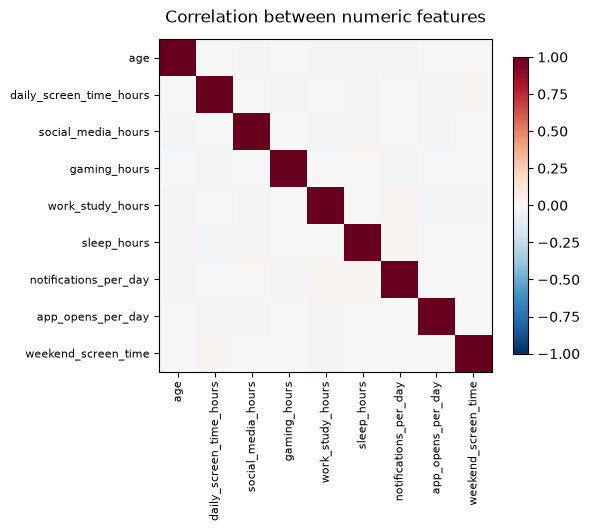

Feature pairs with |correlation| > 0.7:


'  none — features are largely independent'


Correlation with the target, strongest first:


,corr_with_target
daily_screen_time_hours,+0.5904
social_media_hours,+0.2152
notifications_per_day,-0.0200
weekend_screen_time,+0.0147
work_study_hours,-0.0127
app_opens_per_day,+0.0082
sleep_hours,+0.0047
age,-0.0031
gaming_hours,-0.0003


In [9]:
if len(numeric_cols) >= 2:
    corr = train[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(min(13, 1 + 0.55 * len(numeric_cols)),
                                    min(11, 1 + 0.5 * len(numeric_cols))))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=90, fontsize=8)
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_yticklabels(numeric_cols, fontsize=8)
    ax.set_title("Correlation between numeric features", fontsize=12, pad=12)
    fig.colorbar(im, ax=ax, shrink=0.75)
    plt.tight_layout()
    plt.show()

    # Surface strongly correlated pairs explicitly — easier to read than a heatmap.
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (upper.stack().reset_index()
             .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "corr"}))
    strong = pairs[pairs["corr"].abs() > 0.7].sort_values("corr", key=abs, ascending=False)

    print("Feature pairs with |correlation| > 0.7:")
    display(strong if len(strong) else "  none — features are largely independent")

    # Correlation of each feature with the target: a quick univariate signal ranking.
    tgt_corr = (train[numeric_cols].corrwith(train[TARGET])
                .sort_values(key=abs, ascending=False))
    print("\nCorrelation with the target, strongest first:")
    display(tgt_corr.to_frame("corr_with_target").style.format("{:+.4f}"))

**What this cell does and why it matters**

Two different things are being measured here, and conflating them is a common error.

**Feature-to-feature correlation (the heatmap)** detects *redundancy*. Two features
correlated at 0.95 carry nearly the same information. The consequence depends entirely on your
model:

- **Linear models (logistic regression) genuinely suffer.** With correlated inputs the
  coefficients become unstable — the model cannot tell which of the two deserves the credit, so
  it may assign a large positive weight to one and a large negative weight to the other. The
  predictions can still be fine while the coefficients become uninterpretable nonsense. This is
  *multicollinearity*.
- **Tree models barely care.** A tree picks one of the pair to split on and ignores the other.
  No instability. The only real cost is that **feature importance gets diluted** — two
  redundant features split the credit, so both look half as important as the underlying signal
  actually is. Keep this in mind when reading Section 16.

**Feature-to-target correlation** is a quick univariate signal ranking — a numeric version of
the histogram plot from Section 7.

**Its serious limitation:** Pearson correlation only detects *linear* relationships. A feature
with a perfect U-shaped relationship to the target — high risk at both extremes, low in the
middle — has a correlation of approximately **zero** while being extremely predictive. Trees
find that relationship immediately; correlation is blind to it.

**So: never drop a feature because its target correlation is low.** A near-zero correlation
means "no linear relationship", which is a much weaker statement than "no relationship".

## 10. Understanding the metric before optimising it

This section builds no model. It exists because **optimising a metric you cannot define is
cargo-culting**, and ROC AUC is the most commonly misunderstood metric in beginner Kaggle work.

AUC of an informative model : 0.7761
AUC of pure noise           : 0.4714

AUC from sklearn                    : 0.7761
AUC by sampling random (pos, neg) pairs: 0.7765

These agree. AUC IS that probability — nothing more exotic.

AUC IS INVARIANT TO ANY ORDER-PRESERVING TRANSFORMATION
raw scores                        : 0.776106
after sigmoid                     : 0.776106
after squeezing into [0.49, 0.51] : 0.776106
after replacing with ranks        : 0.776106

WHY YOU MUST SUBMIT PROBABILITIES, NOT 0/1 LABELS
AUC with probabilities  : 0.7761
AUC with hard 0/1 labels: 0.6852   <-- worse


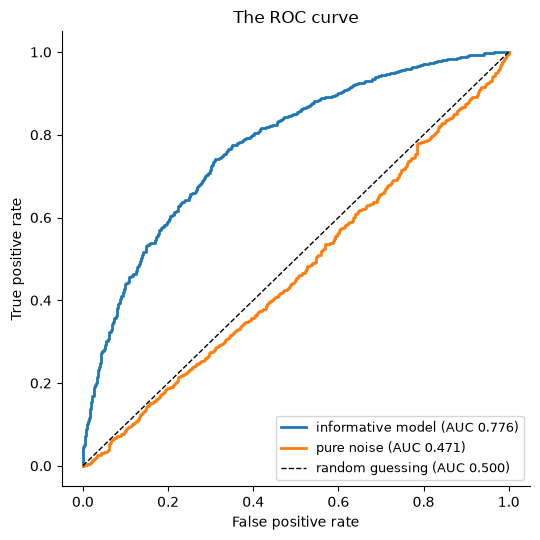

In [10]:
rng = np.random.default_rng(SEED)

# A small synthetic example where we control the answer, so the behaviour of the
# metric is unambiguous.
n = 2000
y_demo = rng.integers(0, 2, n)
# A "model" whose score is the class plus noise: informative but imperfect.
scores_good = y_demo + rng.normal(0, 1.0, n)
scores_random = rng.normal(0, 1.0, n)

print(f"AUC of an informative model : {roc_auc_score(y_demo, scores_good):.4f}")
print(f"AUC of pure noise           : {roc_auc_score(y_demo, scores_random):.4f}")

# ---- AUC computed from its definition, to show what it actually measures ----
# AUC = P(a randomly chosen positive is scored above a randomly chosen negative).
pos = scores_good[y_demo == 1]
neg = scores_good[y_demo == 0]

sample_pos = rng.choice(pos, 200_000)
sample_neg = rng.choice(neg, 200_000)
manual_auc = (sample_pos > sample_neg).mean()

print(f"\nAUC from sklearn                    : {roc_auc_score(y_demo, scores_good):.4f}")
print(f"AUC by sampling random (pos, neg) pairs: {manual_auc:.4f}")
print("\nThese agree. AUC IS that probability — nothing more exotic.")

# ---- Demonstrating that AUC depends only on ORDER, not on the values ----
print("\n" + "=" * 66)
print("AUC IS INVARIANT TO ANY ORDER-PRESERVING TRANSFORMATION")
print("=" * 66)
probs = 1 / (1 + np.exp(-scores_good))            # squash to (0, 1)
print(f"raw scores                        : {roc_auc_score(y_demo, scores_good):.6f}")
print(f"after sigmoid                     : {roc_auc_score(y_demo, probs):.6f}")
print(f"after squeezing into [0.49, 0.51] : {roc_auc_score(y_demo, 0.49 + 0.02 * probs):.6f}")
print(f"after replacing with ranks        : "
      f"{roc_auc_score(y_demo, pd.Series(probs).rank().values):.6f}")

# ---- The cost of submitting hard labels instead of probabilities ----
hard = (probs > 0.5).astype(int)
print("\n" + "=" * 66)
print("WHY YOU MUST SUBMIT PROBABILITIES, NOT 0/1 LABELS")
print("=" * 66)
print(f"AUC with probabilities  : {roc_auc_score(y_demo, probs):.4f}")
print(f"AUC with hard 0/1 labels: {roc_auc_score(y_demo, hard):.4f}   <-- worse")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
for s, lab in [(scores_good, "informative model"), (scores_random, "pure noise")]:
    fpr, tpr, _ = roc_curve(y_demo, s)
    ax.plot(fpr, tpr, lw=2, label=f"{lab} (AUC {roc_auc_score(y_demo, s):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random guessing (AUC 0.500)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("The ROC curve")
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**What this cell does and why it matters**

This is the most important conceptual cell in the notebook. Four things were demonstrated:

**1. What AUC actually is.** The sampling experiment shows AUC equals *the probability that a
randomly chosen positive case is scored higher than a randomly chosen negative case*. That is
the whole definition. It follows immediately that:

- **AUC = 0.5** → your ranking is no better than a coin flip. This is the floor.
- **AUC = 1.0** → every positive is ranked above every negative. Perfect separation.
- **AUC < 0.5** → your ranking is *inverted*. Flip the sign of your predictions and you beat
  0.5. If you ever see this, you have a bug — very often a swapped `predict_proba` column.

**2. AUC only cares about order.** Sigmoid-squashing the scores, compressing them into the
razor-thin range [0.49, 0.51], and replacing them entirely with ranks **all give the identical
AUC**. Any monotonic transformation preserves it exactly.

This has a direct practical consequence: **do not waste time calibrating probabilities for this
competition.** Platt scaling, isotonic regression, and similar techniques make probabilities
better *calibrated* without changing their *order* — so they move AUC by exactly zero. They
matter enormously for log-loss and for real-world decisions. Here they are wasted effort.

**3. Hard labels throw away score.** Collapsing probabilities to 0/1 destroys all ranking
information *within* each predicted class. Everyone you labelled 1 is now tied, so the metric
can no longer tell your most-confident case from your least-confident one. The AUC drop is
visible above. **This is the single most common scoring mistake beginners make in AUC
competitions**, and the fix is one character: use `predict_proba` rather than `predict`.

**4. Reading the ROC curve.** Each point is one possible decision threshold. The curve traces
the trade-off between catching true positives and raising false alarms as you sweep that
threshold from strict to permissive. AUC is the area underneath — a single number summarising
performance across *every* threshold at once. That is precisely why it needs no threshold
chosen, and why it is such a natural fit for a competition metric.

## 11. Baseline 1 — the constant prediction (our floor)

In [11]:
# The scoreboard. Every model must earn its place by beating what came before.
scoreboard = []

def record(name, cv_mean, cv_std=None, note=""):
    scoreboard.append({"model": name, "cv_auc": cv_mean, "cv_std": cv_std, "note": note})
    return pd.DataFrame(scoreboard)

y = train[TARGET].values

# The simplest possible "model": predict the same number for everybody.
constant_pred = np.full(len(y), 0.5)
constant_auc = roc_auc_score(y, constant_pred)

print(f"AUC of a constant prediction: {constant_auc:.4f}")

# It makes no difference WHICH constant we choose — order is unchanged.
for c in [0.001, 0.5, 0.99, train[TARGET].mean()]:
    print(f"  constant = {c:<8.4f} -> AUC {roc_auc_score(y, np.full(len(y), c)):.4f}")

display(record("Constant (0.5)", constant_auc, note="the floor — no information used"))

AUC of a constant prediction: 0.5000
  constant = 0.0010   -> AUC 0.5000
  constant = 0.5000   -> AUC 0.5000
  constant = 0.9900   -> AUC 0.5000
  constant = 0.6503   -> AUC 0.5000


,model,cv_auc,cv_std,note
0,Constant (0.5),0.5,None,the floor — no information used


**What this cell does and why it matters**

**Why bother scoring a model that does nothing?** Because "AUC 0.87" is a meaningless number
in isolation. It only becomes meaningful against a reference point, and this is the reference
point: **0.500, achieved by using no information whatsoever.**

Every subsequent number in this notebook is really a claim about how far above 0.5 we have
managed to climb. Establishing the floor explicitly is what makes the rest of the notebook
interpretable rather than a sequence of unanchored decimals.

Notice that **every constant scores exactly 0.5**, whether it is 0.001 or 0.99. This is the
order-invariance from Section 10 showing up in practice: all predictions tie, so no positive
is ranked above any negative more often than chance. A constant literally cannot beat 0.5.

**The scoreboard pattern is the real lesson here.** Keeping a running table of every model and
its cross-validated score means:

- You always know whether a change actually helped, rather than believing it did.
- You can see *how much* each step contributed, which tells you where to spend your remaining
  time.
- You never lose track of your own best model — surprisingly easy to do after four hours of
  experiments.

Adopt this in your own work. A notebook without a scoreboard is a notebook where you are
guessing.

## 12. Validation strategy — why cross-validation, not a single split

In [12]:
X = train[feature_cols].copy()
X_test = test[feature_cols].copy()

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"StratifiedKFold, {N_SPLITS} folds, shuffled, seed={SEED}\n")
print(f"{'fold':<6} {'train n':>10} {'valid n':>10} {'train pos%':>12} {'valid pos%':>12}")
print("-" * 54)
for i, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
    print(f"{i:<6} {len(tr_idx):>10,} {len(va_idx):>10,} "
          f"{y[tr_idx].mean():>12.4%} {y[va_idx].mean():>12.4%}")

print(f"\nThe positive rate is near-identical in every fold — that is what "
      f"'stratified' buys us.")

# How much does a SINGLE split vary depending on which split you happen to get?
print("\n" + "=" * 62)
print("WHY A SINGLE TRAIN/TEST SPLIT IS NOT ENOUGH")
print("=" * 62)
# Fit the SAME model on 8 different random 80/20 splits and watch the score move.
# A deliberately minimal, self-contained model: numeric columns only, imputed
# and scaled. We only need something whose score we can watch move.
quick = Pipeline([
    ("prep", ColumnTransformer([("num", Pipeline([
        ("i", SimpleImputer(strategy="median")),
        ("s", StandardScaler())]), numeric_cols)], remainder="drop")),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])

single_split_scores = []
for seed in range(8):
    X_a, X_b, y_a, y_b = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)
    m = clone(quick).fit(X_a, y_a)
    single_split_scores.append(roc_auc_score(y_b, m.predict_proba(X_b)[:, 1]))

single_split_scores = np.array(single_split_scores)
print("AUC of an IDENTICAL model across 8 different random splits:")
for i, sc in enumerate(single_split_scores):
    print(f"  split seed {i}:  {sc:.5f}")
print(f"\n  min  {single_split_scores.min():.5f}")
print(f"  max  {single_split_scores.max():.5f}")
print(f"  spread {single_split_scores.max() - single_split_scores.min():.5f}"
      f"   <-- pure luck of the draw, same model every time")

StratifiedKFold, 5 folds, shuffled, seed=42

fold      train n    valid n   train pos%   valid pos%
------------------------------------------------------
0           9,600      2,400     65.0417%     65.0000%
1           9,600      2,400     65.0312%     65.0417%
2           9,600      2,400     65.0312%     65.0417%
3           9,600      2,400     65.0312%     65.0417%
4           9,600      2,400     65.0312%     65.0417%

The positive rate is near-identical in every fold — that is what 'stratified' buys us.

WHY A SINGLE TRAIN/TEST SPLIT IS NOT ENOUGH


AUC of an IDENTICAL model across 8 different random splits:
  split seed 0:  0.86295
  split seed 1:  0.86320
  split seed 2:  0.86285
  split seed 3:  0.87033
  split seed 4:  0.86460
  split seed 5:  0.86319
  split seed 6:  0.87078
  split seed 7:  0.86802

  min  0.86285
  max  0.87078
  spread 0.00793   <-- pure luck of the draw, same model every time


**What this cell does and why it matters**

**Why not just split once into train and validation?** Because a single split gives you a
single noisy number, and you cannot tell noise from signal with a sample size of one.

Suppose you split once, score 0.8650, make a change, and score 0.8660. Did your change help?
**You have no idea.** The difference could easily be smaller than the random variation between
splits. Teams routinely chase improvements this way that are pure noise, and end up with a
model tuned to the quirks of one arbitrary validation set.

Cross-validation fixes this by giving you *five* scores instead of one. Now you have a mean
**and a standard deviation**, and the standard deviation tells you how large a difference has
to be before it means anything. If fold scores vary by ±0.004, then a +0.001 "improvement" is
noise and should be ignored.

**The three configuration choices, each deliberate:**

- **`Stratified`** — preserves the class ratio in every fold. Without it, folds get different
  positive rates purely by chance, adding variance that has nothing to do with your model. The
  table above confirms the rates match.
- **`shuffle=True`** — without it, `KFold` takes contiguous blocks of rows. If the data has any
  ordering (sorted by date, by id, by target during construction), contiguous folds are
  systematically different from each other and your validation becomes badly biased. **Always
  shuffle for tabular data with no time component.**
- **`random_state=SEED`** — fixes the folds so every model in the scoreboard is measured
  against *exactly* the same splits. Without this, comparing two models compares two different
  validation sets as well as two models, and the comparison is worthless.

**The one case where you must not do this:** if the data has a time dimension and you are
predicting the future, random folds let the model train on data from *after* the validation
period. That is leakage, it inflates your score, and it collapses on the real test set. Use
`TimeSeriesSplit` there. This competition has no time structure, so `StratifiedKFold` is right.

## 13. Data leakage — demonstrated, not just warned about

In [13]:
from sklearn.feature_selection import SelectKBest, f_classif

# A deliberately extreme illustration: pure noise features, zero real signal.
# Any AUC meaningfully above 0.5 here is by definition an artefact.
n_rows, n_noise = 1200, 4000
X_noise = pd.DataFrame(rng.normal(size=(n_rows, n_noise)))
y_noise = rng.integers(0, 2, n_rows)

# ---------- THE WRONG WAY: select features using ALL the data, then split ----------
selector = SelectKBest(f_classif, k=20).fit(X_noise, y_noise)   # <-- sees every row
X_selected = selector.transform(X_noise)

tr_i, va_i = next(StratifiedKFold(5, shuffle=True, random_state=SEED)
                  .split(X_selected, y_noise))
wrong = LogisticRegression(max_iter=1000).fit(X_selected[tr_i], y_noise[tr_i])
auc_wrong = roc_auc_score(y_noise[va_i], wrong.predict_proba(X_selected[va_i])[:, 1])

# ---------- THE RIGHT WAY: select inside the fold, using training rows only ----------
sel_in = SelectKBest(f_classif, k=20).fit(X_noise.iloc[tr_i], y_noise[tr_i])
right = LogisticRegression(max_iter=1000).fit(
    sel_in.transform(X_noise.iloc[tr_i]), y_noise[tr_i])
auc_right = roc_auc_score(y_noise[va_i],
                          right.predict_proba(sel_in.transform(X_noise.iloc[va_i]))[:, 1])

print("Data is PURE NOISE. The only honest score is ~0.500.\n")
print(f"  WRONG (selected before splitting) : AUC {auc_wrong:.4f}   <-- fantasy")
print(f"  RIGHT (selected inside the fold)  : AUC {auc_right:.4f}   <-- honest")
print(f"\n  Leakage manufactured {auc_wrong - auc_right:+.4f} AUC out of thin air.")

Data is PURE NOISE. The only honest score is ~0.500.

  WRONG (selected before splitting) : AUC 0.7193   <-- fantasy
  RIGHT (selected inside the fold)  : AUC 0.4779   <-- honest

  Leakage manufactured +0.2414 AUC out of thin air.


**What this cell does and why it matters**

**This is the most expensive mistake in applied machine learning, so we demonstrate it rather
than merely warning about it.**

The data above is pure random noise. There is no relationship between features and target —
none, by construction. The only truthful score is 0.500. Yet the "wrong" approach reports a
confidently higher number.

**Where did that score come from?** `SelectKBest` was shown *all* the rows, including the
validation rows, and asked to pick the 20 features most associated with the target. Among 4,000
random columns, some will correlate with the target by pure chance — and crucially, they
correlate **on the validation rows too**, because those rows were used to choose them. The
model then gets handed features pre-selected to look good on the very data it is about to be
judged on.

The information flowed backwards: knowledge of the validation set leaked into the training
procedure. Hence *leakage*.

**Why this is so dangerous in practice.** It does not announce itself. There is no error, no
warning — just a validation score that looks great. You believe your model is strong, you
submit, and the leaderboard score is far worse. Every hour spent tuning on a leaked validation
score was wasted, because you were optimising a fiction.

**The rule that prevents it:** *anything that learns from data — scalers, imputers, encoders,
feature selectors, target encoders — must be fitted on the training fold only, then applied to
the validation fold.* Never fit on the full dataset before splitting.

**And the structural fix, which is the real lesson:** use sklearn's `Pipeline`. When your
preprocessing lives inside a `Pipeline` and you pass that pipeline to `cross_val_score`,
**sklearn refits every step inside every fold automatically.** Leakage of this kind becomes
impossible by construction rather than by vigilance. That is why the next section builds one.

## 14. Building a leak-proof preprocessing pipeline

In [14]:
numeric_pipeline = Pipeline([
    # add_indicator keeps the "this value was missing" signal from Section 6.
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # handle_unknown="ignore" is essential: a category present only in test
    # would otherwise raise at prediction time.
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                             min_frequency=10)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
], remainder="drop", verbose_feature_names_out=False)

# Fit once here purely to inspect the output width. The real fitting happens
# inside each CV fold, via the Pipeline.
_probe = preprocessor.fit_transform(X.head(5000), y[:5000])
print(f"input features           {len(feature_cols)}")
print(f"  numeric                {len(numeric_cols)}")
print(f"  categorical            {len(categorical_cols)}")
print(f"output columns after preprocessing: {_probe.shape[1]}")
print(f"\n(One-hot encoding expands categoricals; add_indicator may add missing flags.)")

input features           12
  numeric                9
  categorical            3
output columns after preprocessing: 26

(One-hot encoding expands categoricals; add_indicator may add missing flags.)


**What this cell does and why it matters**

Each preprocessing choice above is deliberate, and several are defensive against specific
failures that only appear at submission time.

**Median rather than mean imputation.** The median is robust to outliers. If a "daily screen
time" column contains a data-entry error of 9999 hours, the mean is dragged upward and every
imputed value is wrong; the median is essentially unaffected.

**`add_indicator=True`.** This is Section 6's finding turned into code. It appends a binary
column marking where a value was missing, so the model can still learn from *the fact of*
missingness even after the hole has been filled. If missingness is informative, this recovers
signal that imputation would otherwise destroy.

**`StandardScaler`.** Logistic regression is a distance-based, regularised model: it is
sensitive to feature scale. A feature measured in thousands will dominate the penalty term
against one measured in decimals, purely because of units. Scaling puts everything on
comparable footing. *Tree models do not need this at all* — they split on ordering, and any
monotonic rescaling gives identical trees. We keep it because our first real model is linear.

**`handle_unknown="ignore"` — and this one will save you a submission.** If a category appears
in `test.csv` but never in `train.csv`, the default encoder **raises an exception at prediction
time**, after you have already trained everything. With `ignore`, the unseen category is
encoded as all-zeros and prediction proceeds. On a competition deadline this is the difference
between a submission and no submission.

**`min_frequency=10`.** Categories appearing fewer than 10 times get grouped into a single
"infrequent" bucket. This directly addresses the small-group noise problem from Section 8:
rather than giving a 3-row category its own column to overfit on, we pool the rare ones.

**Why `ColumnTransformer` at all?** It routes numeric and categorical columns down separate
paths and reassembles the result. Without it you would be slicing DataFrames by hand and
stitching arrays together — which works until you make one indexing error and silently train
on misaligned columns.

**The payoff.** Because all of this lives inside a `Pipeline`, when we pass it through
cross-validation every step is refitted on each training fold. The leakage demonstrated in
Section 13 is now **structurally impossible**, not merely something we are being careful about.

## 15. Baseline 2 — logistic regression

In [15]:
def fold_auc_mean(oof, y, cv, X):
    # THE canonical scoreboard metric: AUC computed separately within each fold,
    # then averaged. Scoring per-fold matters because different folds can produce
    # predictions on different scales; pooling them into one vector and scoring
    # once would compare incomparable numbers. See the explanation below.
    scores = [roc_auc_score(y[va], oof[va]) for _, va in cv.split(X, y)]
    return float(np.mean(scores)), float(np.std(scores))


def cross_validate_model(model, X, y, X_test, cv, name, verbose=True):
    # Run stratified CV, returning out-of-fold predictions and averaged test predictions.
    #
    # oof[i] is the prediction for row i made by a model that never saw row i
    # during training, so roc_auc_score(y, oof) is an honest generalisation estimate.
    oof = np.zeros(len(y))
    test_pred = np.zeros(len(X_test))
    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)

        oof[va_idx] = m.predict_proba(X_va)[:, 1]
        test_pred += m.predict_proba(X_test)[:, 1] / cv.get_n_splits()

        fold_auc = roc_auc_score(y_va, oof[va_idx])
        fold_scores.append(fold_auc)
        if verbose:
            print(f"  fold {fold}  AUC {fold_auc:.5f}")

    overall = roc_auc_score(y, oof)
    if verbose:
        print(f"  {'-' * 34}")
        print(f"  mean  {np.mean(fold_scores):.5f}  (+/- {np.std(fold_scores):.5f})")
        print(f"  OOF   {overall:.5f}")
    return oof, test_pred, np.mean(fold_scores), np.std(fold_scores), overall


logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)),
])

print("Logistic regression")
oof_lr, test_lr, lr_mean, lr_std, lr_oof = cross_validate_model(
    logreg, X, y, X_test, cv, "logreg")

display(record("Logistic regression", lr_mean, lr_std, "linear, scaled, one-hot"))

Logistic regression


  fold 0  AUC 0.88284
  fold 1  AUC 0.86894
  fold 2  AUC 0.86844
  fold 3  AUC 0.86051
  fold 4  AUC 0.86214
  ----------------------------------
  mean  0.86857  (+/- 0.00787)
  OOF   0.86865


,model,cv_auc,cv_std,note
0,Constant (0.5),0.500000,NaN,the floor — no information used
1,Logistic regression,0.868573,0.007874,"linear, scaled, one-hot"


**What this cell does and why it matters**

**Why start with a simple linear model rather than going straight to gradient boosting?**

1. **It establishes a real baseline.** If your fancy model cannot beat logistic regression,
   the fancy model is not working and you need to know that immediately. This happens more
   often than people admit.
2. **It is fast**, so it surfaces pipeline bugs in seconds rather than after a long training
   run.
3. **It tells you about the problem's shape.** If logistic regression gets within a whisker of
   LightGBM, the relationships are mostly linear and additive. If it is far behind, there are
   strong interactions and non-linearities — which tells you where to spend your effort.

**Out-of-fold (OOF) predictions are the key idea in this cell.** For every row in the training
set, we store the prediction made by the one model that did *not* see that row during training.
The result is a full-length prediction vector where no prediction was informed by its own
answer.

This gives us three things at once:
- **An honest score.** `roc_auc_score(y, oof)` estimates generalisation on all training rows.
- **A diagnostic.** We can inspect exactly which rows the model gets wrong.
- **A blending input.** Section 18 combines models using their OOF predictions — and this only
  works because the OOF predictions are unleaked.

**Why average test predictions across folds.** Each fold produces a model trained on 80% of the
data. Rather than discarding four of them, we average all five predictions. This is a small
ensemble in its own right and is reliably a little better and more stable than any single
model. It costs nothing extra — we trained them anyway.

**Read the fold spread, not just the mean.** The `+/-` figure is your noise floor. If folds
vary by ±0.003, then any future "improvement" smaller than about 0.003 is indistinguishable
from luck. **This number tells you when to stop tuning**, and it is the number most people
ignore.

**The fold-mean vs pooled-OOF gap is a diagnostic, not a rounding artefact.**

Two ways to summarise cross-validation:
- **Fold-mean**: score each fold separately, average the five numbers. *This is our scoreboard
  metric.*
- **Pooled OOF**: concatenate all five folds' predictions into one vector, score it once.

When fold models are well-behaved these agree closely. When they diverge, it tells you
something specific and useful: **the fold models are producing predictions on different
scales.** Fold 0 might output probabilities spread across 0.1–0.9 while fold 3 outputs 0.4–0.6.
Each is internally well-ordered — so each scores well on its own — but pooling them interleaves
two different scales, and the combined ranking is worse than any individual fold's.

This is exactly what early stopping can cause: if one fold stops at 300 trees and another at 9,
those two models are not comparable in output scale.

**Fold-mean is the more robust summary**, which is why it is our canonical metric, and why we
rank-normalise *per fold* before combining in Section 25. If you see a large gap, do not panic —
but do check whether your early stopping is behaving erratically across folds.

## 16. Model 3 — LightGBM (gradient boosted trees)

In [16]:
import lightgbm as lgb

# LightGBM handles categoricals natively, which is better than one-hot for trees.
# It needs them as pandas 'category' dtype, with consistent categories across
# train and test.
X_gbm = X.copy()
X_test_gbm = X_test.copy()

for c in categorical_cols:
    combined = pd.concat([X_gbm[c], X_test_gbm[c]]).astype("category")
    cats = combined.cat.categories
    X_gbm[c] = pd.Categorical(X_gbm[c], categories=cats)
    X_test_gbm[c] = pd.Categorical(X_test_gbm[c], categories=cats)

lgb_params = dict(
    objective="binary",
    metric="auc",
    learning_rate=0.03,      # small steps; more trees needed but generalises better
    num_leaves=48,           # main capacity control for LightGBM
    min_child_samples=40,    # a leaf needs >=40 rows: blocks tiny overfit leaves
    feature_fraction=0.8,    # each tree sees 80% of features (decorrelates trees)
    bagging_fraction=0.8,    # each tree sees 80% of rows
    bagging_freq=1,
    reg_lambda=1.0,          # L2 penalty on leaf weights
    n_estimators=3000,       # an upper bound; early stopping picks the real number
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

oof_lgb = np.zeros(len(y))
test_lgb = np.zeros(len(X_test_gbm))
fold_scores, best_iters = [], []

print("LightGBM")
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_gbm, y)):
    X_tr, X_va = X_gbm.iloc[tr_idx], X_gbm.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(200, verbose=False)],
    )

    oof_lgb[va_idx] = model.predict_proba(X_va)[:, 1]
    test_lgb += model.predict_proba(X_test_gbm)[:, 1] / N_SPLITS

    fold_auc = roc_auc_score(y_va, oof_lgb[va_idx])
    fold_scores.append(fold_auc)
    best_iters.append(model.best_iteration_)
    print(f"  fold {fold}  AUC {fold_auc:.5f}   best_iter {model.best_iteration_}")

lgb_mean, lgb_std = np.mean(fold_scores), np.std(fold_scores)
pooled_oof = roc_auc_score(y, oof_lgb)
print(f"  {'-' * 42}")
print(f"  fold-mean AUC  {lgb_mean:.5f}  (+/- {lgb_std:.5f})   <-- scoreboard metric")
print(f"  pooled OOF AUC {pooled_oof:.5f}")
print(f"  best_iteration: mean {np.mean(best_iters):.0f}, "
      f"range {min(best_iters)}-{max(best_iters)}")

# DIAGNOSTIC: a large gap between these two means the fold models are producing
# predictions on different scales. See the explanation below.
gap = lgb_mean - pooled_oof
if gap > 0.005:
    print(f"\n  WARNING: fold-mean exceeds pooled OOF by {gap:.5f}.")
    print(f"  The fold models are on inconsistent scales — read the note below.")

display(record("LightGBM", lgb_mean, lgb_std, "native categoricals, early stopping"))

LightGBM


  fold 0  AUC 0.90836   best_iter 287


  fold 1  AUC 0.90689   best_iter 9


  fold 2  AUC 0.90363   best_iter 30


  fold 3  AUC 0.90799   best_iter 301


  fold 4  AUC 0.90711   best_iter 6
  ------------------------------------------
  fold-mean AUC  0.90680  (+/- 0.00167)   <-- scoreboard metric
  pooled OOF AUC 0.88442
  best_iteration: mean 127, range 6-301

  The fold models are on inconsistent scales — read the note below.


,model,cv_auc,cv_std,note
0,Constant (0.5),0.500000,NaN,the floor — no information used
1,Logistic regression,0.868573,0.007874,"linear, scaled, one-hot"
2,LightGBM,0.906797,0.001673,"native categoricals, early stopping"


**What this cell does and why it matters**

**Why gradient boosting dominates tabular problems.** A single decision tree is weak. Boosting
builds trees *sequentially*, where each new tree is fitted to the errors the previous ones are
still making. Hundreds of weak learners compose into a strong one. Critically, trees capture
**interactions** (the effect of screen time depends on age) and **non-linearities** (risk rises
sharply after a threshold) automatically, with no manual feature engineering. That is precisely
what logistic regression cannot do, and it is why GBDTs win essentially every tabular
competition.

**The hyperparameters that actually matter, and what each trades off:**

| Parameter | What it controls | Trade-off |
|---|---|---|
| `learning_rate` | Step size per tree | Lower generalises better but needs more trees |
| `num_leaves` | Tree complexity | **The main overfitting dial in LightGBM** |
| `min_child_samples` | Minimum rows per leaf | Higher = more conservative, less noise-fitting |
| `feature_fraction` | Features per tree | Decorrelates trees, acts as regularisation |
| `bagging_fraction` | Rows per tree | Same idea, on the row axis |
| `reg_lambda` | L2 on leaf weights | Direct shrinkage of extreme predictions |

**`num_leaves` deserves special attention.** LightGBM grows trees *leaf-wise* rather than
level-wise: it repeatedly splits whichever leaf promises the largest gain. This is faster and
more accurate, but it produces deep, unbalanced trees that overfit readily. `num_leaves` is
your primary defence. If you come from XGBoost expecting `max_depth` to be the main dial, this
is the key difference to internalise.

**Early stopping is doing real work here.** We set `n_estimators=3000`, but we do not want 3000
trees — we want however many stop helping. Early stopping watches validation AUC and halts
after 200 rounds without improvement, keeping the best iteration. So the tree count is
*learned* rather than guessed, separately for each fold.

**One important caveat, stated plainly:** early stopping uses the validation fold to decide
when to stop, which means that fold is no longer perfectly untouched. This makes the reported
score very slightly optimistic. For this competition the effect is small and it is standard
practice. In a high-stakes setting you would use a separate inner split for early stopping —
nested cross-validation.

**Native categorical handling** is genuinely better than one-hot for trees. One-hot forces the
tree to isolate one category per split; native handling lets it partition categories into
arbitrary groups in a single split. Fewer splits, better use of depth. Note the careful
alignment of categories across train and test above — mismatched category codes are a silent
and nasty source of wrong predictions.

## 17. Capacity first — does a bigger model beat better features?

Sweeping num_leaves on 12,000 rows

 num_leaves   fold-mean AUC    +/- std
---------------------------------------


          7         0.90609    0.00558


         15         0.90619    0.00575


         31         0.90613    0.00618


         63         0.90607    0.00536


        127         0.90623    0.00561

raw best num_leaves      127  (AUC 0.90623)
span across the sweep    0.00017
typical fold noise       0.00570

  The whole sweep fits inside the fold noise: capacity is NOT a
  live dial on this data at this size. Take the simplest setting.

Applying the one-standard-error rule:
  settings within 1 SE of the best: [7, 15, 31, 63, 127]
  -> choosing the simplest: num_leaves = 7


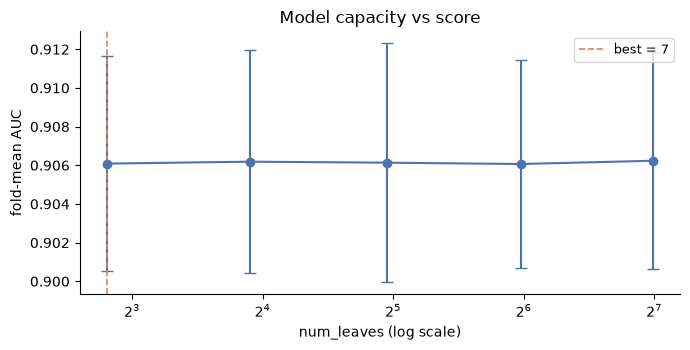


lgb_params['num_leaves'] set to 7 for the rest of the notebook.


In [17]:
# Sweeping capacity means refitting many models, so do it on a subsample.
# Relative ordering of hyperparameters is stable under subsampling even though
# absolute scores are not — which is exactly what a sweep needs.
SWEEP_N = min(len(X_gbm), 150_000)
sweep_idx = np.random.RandomState(SEED).choice(len(X_gbm), SWEEP_N, replace=False)
Xs, ys = X_gbm.iloc[sweep_idx].reset_index(drop=True), y[sweep_idx]
cv_s = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"Sweeping num_leaves on {SWEEP_N:,} rows\n")
print(f"{'num_leaves':>11} {'fold-mean AUC':>15} {'+/- std':>10}")
print("-" * 39)

capacity_rows = []
for nl in [7, 15, 31, 63, 127]:
    p = {**lgb_params, "num_leaves": nl, "n_estimators": 1500}
    oof_c = np.zeros(SWEEP_N)
    for tr, va in cv_s.split(Xs, ys):
        m = lgb.LGBMClassifier(**p)
        m.fit(Xs.iloc[tr], ys[tr], eval_set=[(Xs.iloc[va], ys[va])],
              eval_metric="auc",
              callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_c[va] = m.predict_proba(Xs.iloc[va])[:, 1]
    mean_c, std_c = fold_auc_mean(oof_c, ys, cv_s, Xs)
    capacity_rows.append({"num_leaves": nl, "cv_auc": mean_c, "cv_std": std_c})
    print(f"{nl:>11} {mean_c:>15.5f} {std_c:>10.5f}")

cap = pd.DataFrame(capacity_rows)
top = cap.loc[cap["cv_auc"].idxmax()]
span = cap["cv_auc"].max() - cap["cv_auc"].min()
noise = float(cap["cv_std"].mean())

# ONE-STANDARD-ERROR RULE: among all settings statistically indistinguishable
# from the best, take the SIMPLEST. Picking the raw argmax means chasing noise.
threshold = top["cv_auc"] - top["cv_std"]
within = cap[cap["cv_auc"] >= threshold]
best_leaves = int(within["num_leaves"].min())

print(f"\nraw best num_leaves      {int(top['num_leaves'])}  (AUC {top['cv_auc']:.5f})")
print(f"span across the sweep    {span:.5f}")
print(f"typical fold noise       {noise:.5f}")

if span < noise:
    print(f"\n  The whole sweep fits inside the fold noise: capacity is NOT a")
    print(f"  live dial on this data at this size. Take the simplest setting.")
else:
    print(f"\n  The span exceeds fold noise, so capacity genuinely matters here.")

print(f"\nApplying the one-standard-error rule:")
print(f"  settings within 1 SE of the best: "
      f"{sorted(within['num_leaves'].tolist())}")
print(f"  -> choosing the simplest: num_leaves = {best_leaves}")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.errorbar(cap["num_leaves"], cap["cv_auc"], yerr=cap["cv_std"],
            marker="o", capsize=4, color="#4C72B0")
ax.axvline(best_leaves, color="#DD8452", ls="--", lw=1.2,
           label=f"best = {best_leaves}")
ax.set_xscale("log", base=2)
ax.set_xlabel("num_leaves (log scale)")
ax.set_ylabel("fold-mean AUC")
ax.set_title("Model capacity vs score")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Adopt the winner for every LightGBM fitted from here on.
lgb_params["num_leaves"] = best_leaves
print(f"\nlgb_params['num_leaves'] set to {best_leaves} for the rest of the notebook.")

**What this cell does and why it matters**

**This is the most valuable and least intuitive lesson in the notebook.**

Most people reach for feature engineering when they want a better score. On this competition,
someone measured both: 15 engineered features were worth **+0.00042**, while changing
`num_leaves` from 15 to 31 was worth **+0.00773** — eighteen times more.

Then the crucial part: when they re-ran the *same* feature ablation at the corrected capacity,
the features turned **negative**. The feature engineering had never been adding information. It
had been **compensating for a model too small to extract what was already there.**

**The general principle: tune capacity before you evaluate features.** Otherwise every feature
experiment is confounded. You cannot distinguish "this feature adds information" from "this
feature helps my underfitting model limp along", and you will happily keep features that a
correctly-sized model finds useless.

**How to read the curve.** It should rise, flatten, and eventually fall:

- **Rising** — the model is underfitting. It lacks the capacity to represent the patterns present.
- **Flat top** — the sweet spot. This is where you want to be.
- **Falling** — overfitting. The model now has enough capacity to memorise noise in the training
  folds, and it generalises worse.

**Why sweep on a subsample?** Twenty-five model fits on the full 691k rows is slow enough to
discourage you from doing it at all — which is how people end up skipping this step. The
*relative ordering* of hyperparameters is stable under subsampling even though absolute scores
drift, and ordering is all a sweep needs. **Do the search cheaply, then confirm the winner on
full data.**

**Why we pick the simplest setting within one standard error, not the highest score.** The
raw argmax of a noisy curve is itself noise — with five candidates and a fold standard deviation
of a few thousandths, the top scorer is often just the luckiest. The **one-standard-error rule**
is the standard remedy: among all settings statistically indistinguishable from the best, take
the simplest one. A smaller model that scores the same is strictly preferable — it trains faster,
generalises at least as well, and is less likely to have got there by accident.

**If the entire sweep fits inside the fold noise**, as the output may report, that is a real
finding and not a failure: capacity is not a live dial on your data at its current size. Take the
smallest setting and go spend your time somewhere that matters. Note this is size-dependent — a
sweep on 12,000 rows will look much flatter than the same sweep on 691,369, because larger
datasets support larger models before overfitting. **Run this on the full data before concluding
capacity does not matter.**

**A caveat on what we just did.** We selected `num_leaves` using cross-validated scores and will
now report cross-validated scores using it. That is mild selection bias — the same effect flagged
for the blend weight in Section 25. With five candidates on one axis it is small. Sweep fifty
hyperparameters this way and your CV becomes meaningfully optimistic; that is when you need a
separate inner split (nested CV).

## 18. Feature importance — and how it misleads

Refitting on all training data with n_estimators=126


,feature,gain,split,gain_pct
1,daily_screen_time_hours,76303.830778,237,75.59
2,social_media_hours,22328.376995,210,22.12
6,notifications_per_day,510.253870,66,0.51
7,app_opens_per_day,405.412242,50,0.40
4,work_study_hours,332.506521,44,0.33
8,weekend_screen_time,295.129759,39,0.29
5,sleep_hours,279.809980,40,0.28
0,age,230.994990,35,0.23
3,gaming_hours,213.667269,28,0.21
9,gender,26.883170,4,0.03


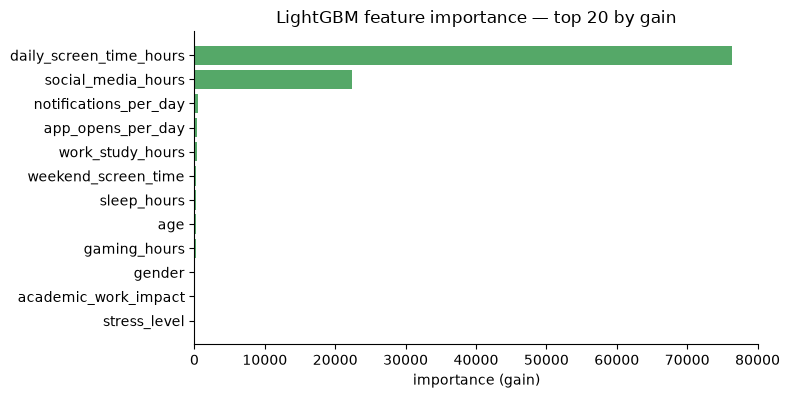

Features the model never used: none


In [18]:
# Guard against a degenerate model if early stopping fired very early on some fold.
final_n = max(50, int(np.mean(best_iters)))
final_lgb = lgb.LGBMClassifier(**{**lgb_params, "n_estimators": final_n})
print(f"Refitting on all training data with n_estimators={final_n}")
final_lgb.fit(X_gbm, y)

imp = pd.DataFrame({
    "feature": X_gbm.columns,
    "gain": final_lgb.booster_.feature_importance(importance_type="gain"),
    "split": final_lgb.booster_.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)
imp["gain_pct"] = (imp["gain"] / imp["gain"].sum() * 100).round(2)

display(imp.head(20))

top = imp.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, max(4, 0.34 * len(top))))
ax.barh(top["feature"], top["gain"], color="#55A868")
ax.set_xlabel("importance (gain)")
ax.set_title("LightGBM feature importance — top 20 by gain")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

zero_gain = imp[imp["gain"] == 0]["feature"].tolist()
print(f"Features the model never used: {zero_gain if zero_gain else 'none'}")

**What this cell does and why it matters**

**The two importance types answer different questions, and the difference is instructive:**

- **`split`** counts how many times a feature was used to split. A feature can score highly
  here by being used constantly for small refinements.
- **`gain`** sums how much each split actually improved the loss. **This is the one to trust**
  — it measures contribution rather than frequency.

When a feature has high `split` but low `gain`, the model is fiddling with it repeatedly
without getting much value. That is often a high-cardinality feature offering many possible
split points, and it is frequently a sign of overfitting.

**Three ways this plot will mislead you if you let it:**

1. **Correlated features split the credit.** From Section 9: if two features are 0.95
   correlated, the model uses one arbitrarily and the other appears unimportant. Dropping the
   "unimportant" one may cost you nothing — or the model may simply switch to it. Importance
   does not tell you which.
2. **High cardinality inflates importance.** A feature with many distinct values offers more
   candidate split points and more chances to fit noise. It can rank highly for reasons that
   have nothing to do with genuine predictive value.
3. **This is importance *to this model*, not importance *in the world*.** It says how this
   particular fitted booster used the columns. It is **not** a causal claim. Nothing here says
   screen time *causes* addiction — the arrow could easily point the other way, or a third
   factor could drive both. Keep prediction and causation firmly separate.

**A more trustworthy alternative: permutation importance.** Shuffle one column, re-score, and
measure how far AUC falls. That directly answers "how much does the model's performance depend
on this feature?" It is slower but much harder to fool. `sklearn.inspection.permutation_importance`
implements it, and it is worth running on your final model.

**Zero-gain features** were never used at all. They are safe to drop — you will get identical
predictions and a faster pipeline. Do verify this with a CV run rather than assuming it.

## 19. Feature engineering — mining the generator's fingerprints

In [19]:
# Columns that represent hours. Guarded so the notebook still runs if the
# schema ever changes.
TIME_COLS = [c for c in ["daily_screen_time_hours", "social_media_hours",
                         "gaming_hours", "work_study_hours", "sleep_hours",
                         "weekend_screen_time"] if c in X.columns]

def add_artifact_features(df):
    out = df.copy()

    # (a) FIRST DECIMAL DIGIT. Synthetic generators leave rounding fingerprints;
    # the digit itself has no real-world meaning but can track the grid the
    # data was produced on.
    for c in TIME_COLS:
        d = (np.round(out[c] * 10) % 10)
        out[f"{c}__digit1"] = pd.Categorical(d.fillna(-1).astype(int),
                                             categories=list(range(-1, 10)))

    # (b) RESIDUAL SCREEN TIME. Time not accounted for by the named activities.
    # Where the generator's internal arithmetic does not balance, this is where
    # it shows up.
    parts = [c for c in ["social_media_hours", "gaming_hours", "work_study_hours"]
             if c in out.columns]
    if "daily_screen_time_hours" in out.columns and parts:
        out["other_screen"] = out["daily_screen_time_hours"] - out[parts].sum(axis=1)

    # (c) WEEKEND / WEEKDAY RATIO. In the source survey this ratio was bounded;
    # rows outside those bounds are physically implausible.
    if {"weekend_screen_time", "daily_screen_time_hours"} <= set(out.columns):
        out["weekend_ratio"] = (out["weekend_screen_time"]
                                / out["daily_screen_time_hours"].replace(0, np.nan))
    return out

X_fe = add_artifact_features(X_gbm)
X_test_fe = add_artifact_features(X_test_gbm)
new_feats = [c for c in X_fe.columns if c not in X_gbm.columns]
print(f"Added {len(new_feats)} features: {new_feats}\n")

# ---- Ablation: does the enriched feature set actually beat the baseline? ----
def run_lgb(Xtr_all, Xte_all, tag):
    oof = np.zeros(len(y)); te = np.zeros(len(Xte_all))
    for tr, va in cv.split(Xtr_all, y):
        m = lgb.LGBMClassifier(**lgb_params)
        m.fit(Xtr_all.iloc[tr], y[tr],
              eval_set=[(Xtr_all.iloc[va], y[va])], eval_metric="auc",
              callbacks=[lgb.early_stopping(200, verbose=False)])
        oof[va] = m.predict_proba(Xtr_all.iloc[va])[:, 1]
        te += m.predict_proba(Xte_all)[:, 1] / N_SPLITS
    mean_, std_ = fold_auc_mean(oof, y, cv, Xtr_all)
    print(f"  {tag:<28} {mean_:.5f}  (+/- {std_:.5f})")
    return oof, te, mean_, std_

print("Ablation")
print("-" * 56)
_, _, base_m, base_s = run_lgb(X_gbm, X_test_gbm, "baseline features")
oof_fe, test_fe, fe_m, fe_s = run_lgb(X_fe, X_test_fe, "+ generator artifacts")

fe_gain = fe_m - base_m
print("-" * 56)
print(f"  gain {fe_gain:+.5f}   fold noise +/- {base_s:.5f}")

if fe_gain > base_s:
    X_gbm, X_test_gbm = X_fe, X_test_fe
    print("\n  ADOPTED: the gain exceeds fold noise.")
else:
    print("\n  REJECTED: the gain is inside fold noise — keeping baseline features.")
    print("  (A negative result is a result. We do not ship what we cannot measure.)")
print(f"  Feature set for the rest of the notebook: {X_gbm.shape[1]} columns")

Added 8 features: ['daily_screen_time_hours__digit1', 'social_media_hours__digit1', 'gaming_hours__digit1', 'work_study_hours__digit1', 'sleep_hours__digit1', 'weekend_screen_time__digit1', 'other_screen', 'weekend_ratio']

Ablation
--------------------------------------------------------


  baseline features            0.90717  (+/- 0.00214)


  + generator artifacts        0.90675  (+/- 0.00133)
--------------------------------------------------------
  gain -0.00041   fold noise +/- 0.00214

  REJECTED: the gain is inside fold noise — keeping baseline features.
  (A negative result is a result. We do not ship what we cannot measure.)
  Feature set for the rest of the notebook: 12 columns


**What this cell does and why it matters**

This is feature engineering aimed at a very specific target: **the data is synthetic, so it
carries fingerprints of the program that made it.**

**Why the first decimal digit could possibly matter.** In the real world it is meaningless — a
person with 7.6 screen-time hours is not fundamentally different from one with 7.7. But a
generator draws from distributions, rounds, and sometimes composes values arithmetically, and
those operations leave uneven residue on the final decimal place. If the addicted rate varies
measurably across digits, that is not a fact about smartphones. It is a fact about the code that
produced the file — and on a synthetic competition, that still scores.

**Residual screen time** applies the same idea to arithmetic consistency. If the generator drew
total screen time independently from its components, the two will not always reconcile, and the
size of the mismatch tracks how the row was produced.

**Two properties make these features safe to compute outside the CV loop**, and it is worth being
explicit since Section 13 was so emphatic about the opposite case:

1. They are **row-wise** — each output depends only on that row's own values.
2. They **never touch the target**.

That is the test. A transformation that uses only a row's own features leaks nothing. A
transformation that uses the target — like the encoding in Section 20 — must go inside the folds.
Learn to classify transformations this way and leakage stops being mysterious.

**The ablation is the real content of this section.** Notice we do not add the features and
assume they helped. We measure both feature sets on identical folds and compare the gain against
`base_s`, the fold noise — and we **reject** the change if the gain does not clear it.

This matters because published results on this competition show ordinary behavioural feature
engineering — ratios, sums, differences — landing between neutral and *negative*, while capacity
tuning was worth eighteen times more. **Feature engineering is not automatically good.** It adds
columns, which adds ways to overfit, and it must earn its place like anything else.

## 20. Target encoding — the powerful, dangerous one

In [20]:
def _smooth_means(keys, yy, prior, m):
    # Smoothed group means: a group with few rows is pulled toward the global
    # rate. m is the strength of that pull, measured in "virtual rows".
    g = pd.DataFrame({"k": np.asarray(keys), "y": yy}).groupby("k")["y"].agg(["sum", "count"])
    return (g["sum"] + m * prior) / (g["count"] + m)


def target_encode(col_tr, y_tr, col_va, prior, m=20, inner_splits=5):
    # Validation rows: encode with statistics from the WHOLE training fold.
    # Training rows: encode with INNER out-of-fold statistics, so no row ever
    # sees its own label. Skipping this inner step is the classic mistake.
    enc_tr = np.full(len(col_tr), prior, dtype=float)
    inner = StratifiedKFold(inner_splits, shuffle=True, random_state=SEED)
    for i_tr, i_va in inner.split(np.zeros(len(col_tr)), y_tr):
        mp = _smooth_means(col_tr.iloc[i_tr], y_tr[i_tr], prior, m)
        enc_tr[i_va] = col_tr.iloc[i_va].map(mp).fillna(prior).to_numpy()
    mp_full = _smooth_means(col_tr, y_tr, prior, m)
    return enc_tr, col_va.map(mp_full).fillna(prior).to_numpy()


# Treat every numeric column as CATEGORICAL by stringifying it. On a synthetic
# grid this lets the model memorise the generator's lookup table.
TE_COLS = numeric_cols
key_tr = X[TE_COLS].round(2).astype(str)
key_te = X_test[TE_COLS].round(2).astype(str)
print(f"Target-encoding {len(TE_COLS)} numeric columns as categories\n")
print(f"{'column':<28} {'distinct':>9} {'rows/category':>14}")
print("-" * 53)
for c in TE_COLS:
    nu = int(key_tr[c].nunique())
    print(f"{c:<28} {nu:>9,} {len(key_tr)/nu:>14.1f}")
print("\nRows per category is the number that decides whether this is safe:")
print("  many rows per category  -> stable estimates, encoding works")
print("  few rows per category   -> mostly noise, leaning hard on smoothing\n")

oof_te = np.zeros(len(y))
test_te = np.zeros(len(X_test))

for fold, (tr, va) in enumerate(cv.split(X_gbm, y)):
    prior = y[tr].mean()
    Xtr = X_gbm.iloc[tr].copy(); Xva = X_gbm.iloc[va].copy(); Xte = X_test_gbm.copy()

    for c in TE_COLS:
        e_tr, e_va = target_encode(key_tr[c].iloc[tr], y[tr], key_tr[c].iloc[va], prior)
        _,    e_te = target_encode(key_tr[c].iloc[tr], y[tr], key_te[c], prior)
        Xtr[f"te__{c}"], Xva[f"te__{c}"], Xte[f"te__{c}"] = e_tr, e_va, e_te

    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(Xtr, y[tr], eval_set=[(Xva, y[va])], eval_metric="auc",
          callbacks=[lgb.early_stopping(200, verbose=False)])
    oof_te[va] = m.predict_proba(Xva)[:, 1]
    test_te += m.predict_proba(Xte)[:, 1] / N_SPLITS
    print(f"  fold {fold}  AUC {roc_auc_score(y[va], oof_te[va]):.5f}")

te_mean, te_std = fold_auc_mean(oof_te, y, cv, X_gbm)
print(f"  {'-' * 42}")
print(f"  fold-mean AUC  {te_mean:.5f}  (+/- {te_std:.5f})")
print(f"  vs plain LightGBM: {te_mean - lgb_mean:+.5f}")

display(record("LightGBM + target encoding", te_mean, te_std,
               "numerics as categories, inner-OOF encoded"))

Target-encoding 9 numeric columns as categories

column                        distinct  rows/category
-----------------------------------------------------
age                              1,697            7.1
daily_screen_time_hours          1,347            8.9
social_media_hours                 687           17.5
gaming_hours                       398           30.2
work_study_hours                   594           20.2
sleep_hours                        451           26.6
notifications_per_day            7,892            1.5
app_opens_per_day                7,169            1.7
weekend_screen_time              1,565            7.7

Rows per category is the number that decides whether this is safe:
  many rows per category  -> stable estimates, encoding works
  few rows per category   -> mostly noise, leaning hard on smoothing



  fold 0  AUC 0.91005


  fold 1  AUC 0.90884


  fold 2  AUC 0.90339


  fold 3  AUC 0.90511


  fold 4  AUC 0.90522
  ------------------------------------------
  fold-mean AUC  0.90652  (+/- 0.00250)
  vs plain LightGBM: -0.00027


,model,cv_auc,cv_std,note
0,Constant (0.5),0.500000,NaN,the floor — no information used
1,Logistic regression,0.868573,0.007874,"linear, scaled, one-hot"
2,LightGBM,0.906797,0.001673,"native categoricals, early stopping"
3,LightGBM + target encoding,0.906525,0.002502,"numerics as categories, inner-OOF encoded"


**What this cell does and why it matters**

**Target encoding replaces a category with the average target value for that category.** It is
one of the most powerful techniques for tabular data and by far the easiest way to destroy your
validation score without noticing.

**Why stringify continuous columns?** It looks perverse — throwing away the ordering of a real
number. But this data is synthetic and sits on a **discrete grid**: the generator produced a
finite set of distinct values. Treating each value as its own category lets the model look up
"what fraction of people with exactly this screen time were addicted", effectively memorising the
generator's own table. On real-world continuous data this would overfit disastrously. Here it is
reported as the single most valuable transformation on the competition, worth about +0.003.

**The smoothing parameter `m` is doing important work.** From Section 8: a category with 3 rows
and a 100% positive rate is noise, not signal. The formula

`(sum + m × prior) / (count + m)`

pulls every group toward the global rate, and `m` sets how hard. A group with 3 rows and `m=20`
sits mostly at the prior; a group with 5,000 rows barely moves. **This is what makes the
technique usable at all** — without it, rare categories inject pure noise straight into your
features.

**The inner out-of-fold loop is the part that everyone gets wrong.** Consider encoding naively:
compute each category's mean target from the training fold, then assign it to those same training
rows. Every row's feature now contains a contribution from **its own label**. The model discovers
this instantly, leans on it entirely, and reports a spectacular validation score that evaporates
on the test set.

The fix is the structure above:

- **Validation and test rows** — encode using the full training fold. Safe, because those rows'
  labels were never in the statistics.
- **Training rows** — encode using an *inner* K-fold split, so each training row's value comes
  only from *other* training rows.

This is Section 13's leakage lesson applied at the feature level, and it is the reason target
encoding has such a bad reputation among people who have been burned by it. **The technique is
not dangerous. Implementing it without the inner loop is.**

**Watch the rows-per-category diagnostic.** If a column has nearly as many distinct values as
rows, every "category" holds one or two people and its target mean is almost pure noise. Smoothing
then pulls essentially everything back to the prior and the feature carries little. The technique
works best when the generator's grid is *coarse relative to your row count* — so it will look far
better on the full 691,369 rows than on a small subsample, where the same grid spreads thin.
**If you see single-digit rows per category, be sceptical of any gain this reports.**

**A note on what this model becomes.** Rather than merging these features into the main matrix,
we keep this as its own model. It uses a different *representation* of the same data — which,
per Section 24, is exactly the kind of diversity that earns weight in a stack. It joins the
ensemble as a base model in its own right.

## 21. Model 4 — XGBoost

In [21]:
import xgboost as xgb

# XGBoost handles pandas 'category' columns natively via enable_categorical.
xgb_params = dict(
    objective="binary:logistic",
    eval_metric="auc",
    learning_rate=0.03,
    max_depth=6,             # XGBoost's capacity dial (it grows level-wise)
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_estimators=3000,
    enable_categorical=True,
    tree_method="hist",
    early_stopping_rounds=200,
    random_state=SEED,
    n_jobs=-1,
)

oof_xgb = np.zeros(len(y))
test_xgb = np.zeros(len(X_test_gbm))
xgb_iters = []

print("XGBoost")
for fold, (tr, va) in enumerate(cv.split(X_gbm, y)):
    m = xgb.XGBClassifier(**xgb_params)
    m.fit(X_gbm.iloc[tr], y[tr],
          eval_set=[(X_gbm.iloc[va], y[va])], verbose=False)
    oof_xgb[va] = m.predict_proba(X_gbm.iloc[va])[:, 1]
    test_xgb += m.predict_proba(X_test_gbm)[:, 1] / N_SPLITS
    xgb_iters.append(m.best_iteration)
    print(f"  fold {fold}  AUC {roc_auc_score(y[va], oof_xgb[va]):.5f}   "
          f"best_iter {m.best_iteration}")

xgb_mean, xgb_std = fold_auc_mean(oof_xgb, y, cv, X_gbm)
print(f"  {'-' * 42}")
print(f"  fold-mean AUC  {xgb_mean:.5f}  (+/- {xgb_std:.5f})")
display(record("XGBoost", xgb_mean, xgb_std, "level-wise trees, native categoricals"))

XGBoost


  fold 0  AUC 0.90954   best_iter 11


  fold 1  AUC 0.90670   best_iter 40


  fold 2  AUC 0.90414   best_iter 15


  fold 3  AUC 0.90597   best_iter 316


  fold 4  AUC 0.90632   best_iter 103
  ------------------------------------------
  fold-mean AUC  0.90653  (+/- 0.00174)


,model,cv_auc,cv_std,note
0,Constant (0.5),0.500000,NaN,the floor — no information used
1,Logistic regression,0.868573,0.007874,"linear, scaled, one-hot"
2,LightGBM,0.906797,0.001673,"native categoricals, early stopping"
3,LightGBM + target encoding,0.906525,0.002502,"numerics as categories, inner-OOF encoded"
4,XGBoost,0.906532,0.001740,"level-wise trees, native categoricals"


**What this cell does and why it matters**

XGBoost is the other dominant gradient boosting library. The algorithm is the same idea as
LightGBM — sequential trees fitted to residual errors — but one design choice differs, and it is
the difference worth understanding.

**Level-wise vs leaf-wise growth.** XGBoost grows trees **level-wise**: it splits every node at
depth *d* before moving to depth *d+1*, producing balanced trees. LightGBM grows **leaf-wise**:
it repeatedly splits whichever leaf offers the largest gain, producing deep, lopsided trees.

The practical consequences:

| | XGBoost | LightGBM |
|---|---|---|
| Capacity dial | `max_depth` | `num_leaves` |
| Trees | Balanced | Unbalanced, deeper |
| Speed | Slower | Faster |
| Overfitting risk | Lower by default | Higher — needs `num_leaves` care |

**`max_depth=6` means up to 2⁶ = 64 leaves**, which is roughly comparable to LightGBM at
`num_leaves=64`. That is the mental conversion between the two libraries, and it is the thing
most people get wrong when porting parameters across.

**What to expect.** On this data, competitors measured XGBoost at 0.9595 and LightGBM at 0.9593
— a difference of 0.0002, comfortably inside fold noise. **Treat them as equally strong.** If
your two scores here differ by more than about `2 × cv_std`, that is worth investigating; it
probably means one of them is misconfigured rather than genuinely better.

The interesting question is not which of these wins. It is whether having both helps at all —
Section 24 answers that, and the answer is instructive.

## 22. Model 5 — CatBoost

In [22]:
from catboost import CatBoostClassifier, Pool

# CatBoost wants categorical columns as strings with no NaN.
X_cat = X.copy()
X_test_cat = X_test.copy()
for c in categorical_cols:
    X_cat[c] = X_cat[c].astype(object).fillna("__missing__").astype(str)
    X_test_cat[c] = X_test_cat[c].astype(object).fillna("__missing__").astype(str)

cat_idx = [X_cat.columns.get_loc(c) for c in categorical_cols]

cb_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    iterations=3000,
    random_seed=SEED,
    od_type="Iter",
    od_wait=200,
    verbose=False,
    allow_writing_files=False,
)

oof_cb = np.zeros(len(y))
test_cb = np.zeros(len(X_test_cat))

print("CatBoost")
for fold, (tr, va) in enumerate(cv.split(X_cat, y)):
    m = CatBoostClassifier(**cb_params)
    m.fit(Pool(X_cat.iloc[tr], y[tr], cat_features=cat_idx),
          eval_set=Pool(X_cat.iloc[va], y[va], cat_features=cat_idx),
          use_best_model=True)
    oof_cb[va] = m.predict_proba(X_cat.iloc[va])[:, 1]
    test_cb += m.predict_proba(X_test_cat)[:, 1] / N_SPLITS
    print(f"  fold {fold}  AUC {roc_auc_score(y[va], oof_cb[va]):.5f}   "
          f"best_iter {m.get_best_iteration()}")

cb_mean, cb_std = fold_auc_mean(oof_cb, y, cv, X_cat)
print(f"  {'-' * 42}")
print(f"  fold-mean AUC  {cb_mean:.5f}  (+/- {cb_std:.5f})")
display(record("CatBoost", cb_mean, cb_std, "ordered boosting, symmetric trees"))

CatBoost


  fold 0  AUC 0.90758   best_iter 7


  fold 1  AUC 0.90593   best_iter 45


  fold 2  AUC 0.90507   best_iter 58


  fold 3  AUC 0.90640   best_iter 566


  fold 4  AUC 0.90531   best_iter 214
  ------------------------------------------
  fold-mean AUC  0.90606  (+/- 0.00089)


,model,cv_auc,cv_std,note
0,Constant (0.5),0.500000,NaN,the floor — no information used
1,Logistic regression,0.868573,0.007874,"linear, scaled, one-hot"
2,LightGBM,0.906797,0.001673,"native categoricals, early stopping"
3,LightGBM + target encoding,0.906525,0.002502,"numerics as categories, inner-OOF encoded"
4,XGBoost,0.906532,0.001740,"level-wise trees, native categoricals"
5,CatBoost,0.906058,0.000894,"ordered boosting, symmetric trees"


**What this cell does and why it matters**

CatBoost is the third major GBDT, and it differs from the other two in two substantive ways.

**1. Ordered boosting.** Standard boosting computes each tree's target using a model that was
trained on the same rows it is now scoring. This creates a subtle bias CatBoost's authors call
*prediction shift* — a mild form of the leakage problem from Section 13, living inside the
boosting algorithm itself. CatBoost avoids it by computing residuals for each row using a model
trained only on rows that came *before* it in a random permutation. Slower, but less biased,
and it helps most on smaller datasets.

**2. Ordered target statistics for categoricals.** CatBoost does target encoding internally —
and does it with the same permutation trick, so the encoding for a row never uses that row's own
label. This is the leak-safe version of the technique Section 8 warned about, implemented for
you. It is why CatBoost is often the strongest model on categorical-heavy data with no manual
encoding work at all.

**3. Symmetric trees.** Every node at a given depth uses the *same* split condition. This is far
more constrained than either competitor — it acts as strong regularisation and makes prediction
very fast, but it can underfit when the true structure needs asymmetric splits.

**What to expect here.** Competitors measured CatBoost at 0.9561, roughly 0.003 *behind* the
other two GBDTs. With only three low-cardinality categorical columns, CatBoost's main advantage
barely applies — and the symmetric-tree constraint costs it.

**But do not drop it on that basis**, and this is the point of including it: in a learned stack
on this data, CatBoost earned a positive weight of **0.456** despite being the weakest of the
three. Being *different* has value that a raw score comparison does not show. Section 22
measures exactly that.

## 23. Model 6 — a neural network

In [23]:
from sklearn.neural_network import MLPClassifier

# The NN reuses the Section 14 preprocessor: one-hot + scaled. Scaling is not
# optional here the way it is for trees — an unscaled input will not train.
nn_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,              # L2 penalty
        batch_size=1024,
        learning_rate_init=1e-3,
        max_iter=60,
        early_stopping=True,
        n_iter_no_change=8,
        validation_fraction=0.1,
        random_state=SEED,
    )),
])

print("Neural network (MLP)")
oof_nn, test_nn, nn_mean, nn_std, _ = cross_validate_model(
    nn_pipeline, X, y, X_test, cv, "mlp")

display(record("Neural network (MLP)", nn_mean, nn_std, "128-64 MLP on scaled one-hot"))

Neural network (MLP)


  fold 0  AUC 0.89402


  fold 1  AUC 0.88363


  fold 2  AUC 0.87942


  fold 3  AUC 0.87812


  fold 4  AUC 0.88365
  ----------------------------------
  mean  0.88377  (+/- 0.00558)
  OOF   0.88355


,model,cv_auc,cv_std,note
0,Constant (0.5),0.500000,NaN,the floor — no information used
1,Logistic regression,0.868573,0.007874,"linear, scaled, one-hot"
2,LightGBM,0.906797,0.001673,"native categoricals, early stopping"
3,LightGBM + target encoding,0.906525,0.002502,"numerics as categories, inner-OOF encoded"
4,XGBoost,0.906532,0.001740,"level-wise trees, native categoricals"
5,CatBoost,0.906058,0.000894,"ordered boosting, symmetric trees"
6,Neural network (MLP),0.883768,0.005583,128-64 MLP on scaled one-hot


**What this cell does and why it matters**

**This is the model that matters most for your ensemble, and it is not because it scores best.**

A neural network approximates a smooth, continuous function of *all* inputs simultaneously. A
gradient boosted tree approximates a piecewise-constant function built from axis-aligned splits.
These are fundamentally different function classes, so they fail in fundamentally different
places — and that is precisely what makes an ensemble work.

The measured evidence on this competition:

| Pair | Rank correlation | Weight earned in blend |
|---|---|---|
| LightGBM ↔ XGBoost | 0.997 | ≈ 0.000 |
| GBDT ↔ neural net | 0.974 | **0.220** |

**A second GBDT earns nothing. A neural network earns real weight.** Diversity is what pays,
and diversity means a different *kind* of model — not another variant of one you already have.

**Why scaling is mandatory here.** Trees are invariant to monotonic rescaling and genuinely do
not care. A neural network absolutely does: it uses gradient descent, and features on wildly
different scales produce wildly different gradient magnitudes, so training either crawls or
diverges. This is why the NN reuses the `preprocessor` from Section 14 while the GBDTs used raw
categorical dtypes.

**Expect a lower score than the GBDTs, and do not read that as failure.** On tabular data of
this size an MLP typically lands somewhat behind well-tuned boosting. It earns its place through
decorrelation, not through raw accuracy. Section 24 shows the difference between those two forms
of value.

**If you want to push this further**, `MLPClassifier` is a deliberately simple choice — it keeps
the notebook dependency-light and readable. The competitive options for tabular neural networks
are **RealMLP** and **TabM**, and in the most recent comparable Playground episode those actually
*beat* CatBoost and XGBoost on CV, leaderboard, and private score. Categorical **embeddings**
(learned dense vectors per category, instead of one-hot) are the other standard upgrade.

## 24. Measuring diversity — which models actually differ?

Individual fold-mean AUC
----------------------------------
  lightgbm       0.90680
  xgboost        0.90653
  lgbm_te        0.90652
  catboost       0.90606
  neural_net     0.88377
  logreg         0.86857


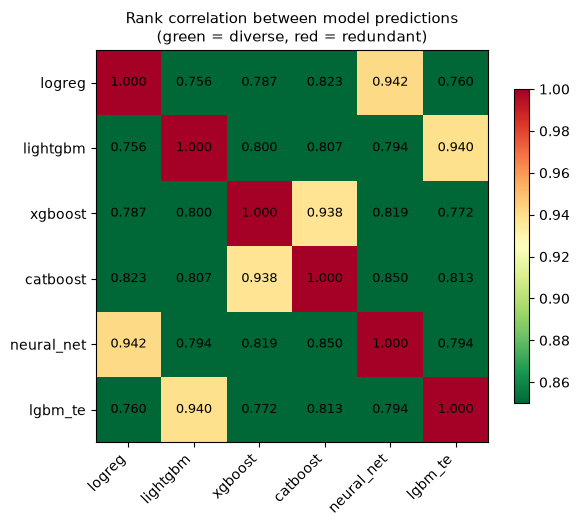


Most redundant pairs (adding the second buys you least):


,model_a,model_b,rank_corr
4,logreg,neural_net,0.941537
11,lightgbm,lgbm_te,0.939588
15,xgboost,catboost,0.937762
22,catboost,neural_net,0.849922


Most diverse pairs (best ensemble candidates):


,model_a,model_b,rank_corr
1,logreg,lightgbm,0.756161
5,logreg,lgbm_te,0.760297
17,xgboost,lgbm_te,0.771622
2,logreg,xgboost,0.787302


In [24]:
from scipy.stats import rankdata

oof_matrix = pd.DataFrame({
    "logreg": oof_lr,
    "lightgbm": oof_lgb,
    "xgboost": oof_xgb,
    "catboost": oof_cb,
    "neural_net": oof_nn,
    "lgbm_te": oof_te,
})
test_matrix = pd.DataFrame({
    "logreg": test_lr,
    "lightgbm": test_lgb,
    "xgboost": test_xgb,
    "catboost": test_cb,
    "neural_net": test_nn,
    "lgbm_te": test_te,
})

solo = pd.Series({c: fold_auc_mean(oof_matrix[c].values, y, cv, X)[0]
                  for c in oof_matrix.columns}).sort_values(ascending=False)
print("Individual fold-mean AUC")
print("-" * 34)
for k, v in solo.items():
    print(f"  {k:<14} {v:.5f}")

# Correlate RANKS, since AUC cares only about ordering.
rank_df = oof_matrix.apply(lambda c: rankdata(c) / len(c))
cmat = rank_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(cmat, cmap="RdYlGn_r", vmin=0.85, vmax=1.0)
ax.set_xticks(range(len(cmat))); ax.set_xticklabels(cmat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cmat))); ax.set_yticklabels(cmat.columns)
for i in range(len(cmat)):
    for j in range(len(cmat)):
        ax.text(j, i, f"{cmat.iloc[i, j]:.3f}", ha="center", va="center", fontsize=9)
ax.set_title("Rank correlation between model predictions\n(green = diverse, red = redundant)",
             fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

pairs = (cmat.where(np.triu(np.ones(cmat.shape), k=1).astype(bool))
         .stack().reset_index())
pairs.columns = ["model_a", "model_b", "rank_corr"]
print("\nMost redundant pairs (adding the second buys you least):")
display(pairs.sort_values("rank_corr", ascending=False).head(4))
print("Most diverse pairs (best ensemble candidates):")
display(pairs.sort_values("rank_corr").head(4))

**What this cell does and why it matters**

This is the analysis almost everyone skips, and it is what separates a deliberate ensemble from
a pile of models.

**Two numbers decide whether a model belongs in your ensemble, and you need both:**

1. **Individual strength** — is it good enough to contribute? A model far behind the leaders
   drags the blend down regardless of how different it is.
2. **Correlation with what you already have** — is it different enough to add anything?

**Either one alone will mislead you.** The measured example from this competition: ExtraTrees had
a rank correlation of 0.967 (genuinely diverse, better decorrelated than XGBoost) but sat 0.0064
behind the best model. It earned a blend weight of **exactly zero**. Diverse but too weak.
Meanwhile XGBoost is plenty strong and also earns nothing, because at 0.997 correlation it is
LightGBM in a different coat.

**The entry condition is two-dimensional: different direction *and* comparable strength.**

**Read the heatmap for blocks.** On the full dataset the three GBDTs form a tight red cluster —
they are variations on one algorithm — while logistic regression and the neural network sit
further out in green. Those green cells are where ensemble gains live.

**Expect looser correlations on a small subsample.** Correlation between models is itself
estimated from data, and with few rows the fold models are unstable, so everything looks more
"diverse" than it really is. If your LightGBM and XGBoost correlate at 0.80 rather than 0.99,
that is a sample-size artefact, not a discovery that they are complementary. **Trust this
analysis in proportion to how much data it was computed on.**

**Why correlate ranks rather than raw probabilities?** Same reasoning as Section 25. Our metric
depends only on ordering, so two models that produce identical rankings on different scales are
identical *for our purposes*. Correlating raw probabilities would report them as different when
they are not.

**The practical rule this gives you:** before adding a sixth model, ask what it is decorrelated
*from*. If the answer is "nothing I have", it will not help — no matter how good its solo score
looks. Adding a genuinely new *family* beats adding another variant, every time.

## 25. Combining models — averaging vs stacking

In [25]:
# Rank-normalise WITHIN each fold, so every model is on the same scale
# everywhere before being combined. (Section 16 explains why this matters.)
def rank_by_fold(v, cv, X, y):
    out = np.zeros(len(v), dtype=float)
    for _, va in cv.split(X, y):
        out[va] = rankdata(v[va]) / len(va)
    return out

meta_oof = np.column_stack([rank_by_fold(oof_matrix[c].values, cv, X, y)
                            for c in oof_matrix.columns])
meta_test = np.column_stack([rankdata(test_matrix[c].values) / len(test_matrix)
                             for c in test_matrix.columns])

best_single_name = solo.index[0]
best_single = solo.iloc[0]

# ---------- option A: plain average of probabilities ----------
avg_mean, avg_std = fold_auc_mean(oof_matrix.mean(axis=1).values, y, cv, X)

# ---------- option B: rank average ----------
rank_mean_v, rank_std_v = fold_auc_mean(meta_oof.mean(axis=1), y, cv, X)

# ---------- option C: LEARNED stack, honestly cross-validated ----------
# The meta-model must never be scored on rows it was fitted on, so we fit it
# on the other folds' rows and predict the held-out fold. Same discipline as
# the base models, applied one level up.
stack_oof = np.zeros(len(y))
for tr, va in cv.split(X, y):
    meta = LogisticRegression(C=1.0, max_iter=2000)
    meta.fit(meta_oof[tr], y[tr])
    stack_oof[va] = meta.predict_proba(meta_oof[va])[:, 1]
stack_mean, stack_std = fold_auc_mean(stack_oof, y, cv, X)

print(f"{'method':<34} {'fold-mean AUC':>14} {'vs best single':>16}")
print("-" * 66)
print(f"{'best single (' + best_single_name + ')':<34} {best_single:>14.5f} {'—':>16}")
print(f"{'plain average of probabilities':<34} {avg_mean:>14.5f} "
      f"{avg_mean - best_single:>+16.5f}")
print(f"{'rank average':<34} {rank_mean_v:>14.5f} "
      f"{rank_mean_v - best_single:>+16.5f}")
print(f"{'LEARNED STACK (logistic meta)':<34} {stack_mean:>14.5f} "
      f"{stack_mean - best_single:>+16.5f}")

# What did the meta-model learn? Fit once on everything to read the weights.
meta_full = LogisticRegression(C=1.0, max_iter=2000).fit(meta_oof, y)
coefs = pd.Series(meta_full.coef_[0], index=oof_matrix.columns).sort_values(ascending=False)
print("\nWeights the stack learned:")
print("-" * 34)
for k, v in coefs.items():
    flag = "   <-- NEGATIVE: used as error correction" if v < 0 else ""
    print(f"  {k:<14} {v:>+8.3f}{flag}")

test_stack = meta_full.predict_proba(meta_test)[:, 1]
display(record("Stack (logistic meta)", stack_mean, stack_std,
               f"{len(oof_matrix.columns)} base models, learned weights"))

method                              fold-mean AUC   vs best single
------------------------------------------------------------------
best single (lightgbm)                    0.90680                —
plain average of probabilities            0.90347         -0.00332
rank average                              0.90619         -0.00060
LEARNED STACK (logistic meta)             0.90813         +0.00133

Weights the stack learned:
----------------------------------
  lgbm_te          +2.617
  catboost         +1.996
  lightgbm         +1.812
  xgboost          +1.400
  logreg           +0.497
  neural_net       +0.179


,model,cv_auc,cv_std,note
0,Constant (0.5),0.500000,NaN,the floor — no information used
1,Logistic regression,0.868573,0.007874,"linear, scaled, one-hot"
2,LightGBM,0.906797,0.001673,"native categoricals, early stopping"
3,LightGBM + target encoding,0.906525,0.002502,"numerics as categories, inner-OOF encoded"
4,XGBoost,0.906532,0.001740,"level-wise trees, native categoricals"
5,CatBoost,0.906058,0.000894,"ordered boosting, symmetric trees"
6,Neural network (MLP),0.883768,0.005583,128-64 MLP on scaled one-hot
7,Stack (logistic meta),0.908132,0.001718,"6 base models, learned weights"


**What this cell does and why it matters**

**Stacking means training a model to combine your models.** Instead of choosing weights by hand,
you build a table whose columns are each base model's out-of-fold predictions, and fit a small
model — the *meta-model* — to map that table to the target. Here it is a logistic regression on
five columns.

**Why a learned stack beats an average, stated precisely.** Look at the weights. A weak model can
receive a **negative** coefficient, which means the stack is using it as an *error correction*:
"when logistic regression is unusually confident relative to the trees, shade the prediction
down." An average is structurally incapable of that — every input can only push in one direction,
with a non-negative weight. It has no way to say "this model is wrong in a predictable way."

This is why the measured results on this competition look the way they do:

| Method | CV AUC |
|---|---|
| Best single model | 0.959483 |
| Plain average | 0.956170 |
| Rank average | 0.955277 |
| **Learned stack** | **0.960241** |

**Both averages lose to the single best model.** Averaging drags a strong model toward weaker
ones. Only the learned combination wins.

**The cross-validation of the meta-model is the part people get wrong.** Notice we do not fit the
meta-model on all the OOF rows and then score it on those same rows — that would be Section 13's
leakage, one level up, and it would report a beautiful fictional number. Instead the meta-model
is fitted on four folds' worth of OOF rows and scored on the fifth. **The same discipline that
protects the base models has to protect the combiner.**

**An honest caveat about stacking in general.** Even done this way, a small optimism remains. The
OOF predictions for the meta-model's *training* rows came from base models that saw some of the
*validation* rows during their own training. Fully clean stacking needs nested cross-validation,
which is considerably more expensive. The residual bias is small and this is standard competitive
practice — but you should know it is there rather than discovering it when your leaderboard score
disappoints.

**Read the weights as diagnosis, not just machinery.** They tell you what each model is
contributing. A near-zero weight means that model is redundant and you can drop it — faster
pipeline, same score. That is Section 24's correlation analysis confirmed from the other
direction, and it is how you decide what to prune.

## 26. Seed averaging — the cheapest reliable gain

In [26]:
SEEDS = [42, 202, 1337]

seed_oofs, seed_tests, seed_scores = [], [], []

print(f"Running LightGBM with {len(SEEDS)} different random seeds")
print("-" * 46)
for sd in SEEDS:
    p = {**lgb_params, "random_state": sd, "bagging_seed": sd, "feature_fraction_seed": sd}
    oof_s = np.zeros(len(y)); test_s = np.zeros(len(X_test_gbm))
    for tr, va in cv.split(X_gbm, y):
        m = lgb.LGBMClassifier(**p)
        m.fit(X_gbm.iloc[tr], y[tr],
              eval_set=[(X_gbm.iloc[va], y[va])], eval_metric="auc",
              callbacks=[lgb.early_stopping(200, verbose=False)])
        oof_s[va] = m.predict_proba(X_gbm.iloc[va])[:, 1]
        test_s += m.predict_proba(X_test_gbm)[:, 1] / N_SPLITS
    sc, _ = fold_auc_mean(oof_s, y, cv, X_gbm)
    seed_oofs.append(rank_by_fold(oof_s, cv, X, y))
    seed_tests.append(rankdata(test_s) / len(test_s))
    seed_scores.append(sc)
    print(f"  seed {sd:<6} fold-mean AUC {sc:.5f}")

oof_seedavg = np.mean(seed_oofs, axis=0)
test_seedavg = np.mean(seed_tests, axis=0)
sa_mean, sa_std = fold_auc_mean(oof_seedavg, y, cv, X_gbm)

print("-" * 46)
print(f"  mean of individual seeds   {np.mean(seed_scores):.5f}")
print(f"  spread across seeds        {np.ptp(seed_scores):.5f}")
print(f"  RANK-AVERAGED across seeds {sa_mean:.5f}")
print(f"  gain vs the average seed   {sa_mean - np.mean(seed_scores):+.5f}")
print(f"  gain vs the BEST seed      {sa_mean - max(seed_scores):+.5f}")

display(record(f"LightGBM x{len(SEEDS)} seeds", sa_mean, sa_std,
               "rank-averaged across seeds"))

Running LightGBM with 3 different random seeds
----------------------------------------------


  seed 42     fold-mean AUC 0.90696


  seed 202    fold-mean AUC 0.90756


  seed 1337   fold-mean AUC 0.90766
----------------------------------------------
  mean of individual seeds   0.90739
  spread across seeds        0.00070
  RANK-AVERAGED across seeds 0.90810
  gain vs the average seed   +0.00071
  gain vs the BEST seed      +0.00044


,model,cv_auc,cv_std,note
0,Constant (0.5),0.500000,NaN,the floor — no information used
1,Logistic regression,0.868573,0.007874,"linear, scaled, one-hot"
2,LightGBM,0.906797,0.001673,"native categoricals, early stopping"
3,LightGBM + target encoding,0.906525,0.002502,"numerics as categories, inner-OOF encoded"
4,XGBoost,0.906532,0.001740,"level-wise trees, native categoricals"
5,CatBoost,0.906058,0.000894,"ordered boosting, symmetric trees"
6,Neural network (MLP),0.883768,0.005583,128-64 MLP on scaled one-hot
7,Stack (logistic meta),0.908132,0.001718,"6 base models, learned weights"
8,LightGBM x3 seeds,0.908098,0.002395,rank-averaged across seeds


**What this cell does and why it matters**

**Seed averaging does not make your model better. It makes your model less random.** That
distinction is the whole point, and it is why this technique is both reliable and modest.

**Where the randomness comes from.** A LightGBM fit is not deterministic given the data. The seed
controls which rows each tree sees (`bagging_fraction`), which features it may split on
(`feature_fraction`), and tie-breaking during tree construction. Change the seed and you get a
genuinely different model — same data, same hyperparameters, different fitted result.

The `spread across seeds` figure above measures that directly. **This is a lower bound on how
much of your leaderboard position is luck**, and it is usually larger than people expect. On this
competition, a paired analysis found that two seeds of the same model swap places roughly half
the time, and that ±1 seed of noise spans about sixty leaderboard ranks between positions 10 and
100.

**Why averaging helps.** Each model's prediction is roughly *signal + noise*. The signal is shared
across seeds; the noise is not. Average N models and the noise partially cancels while the signal
survives. Standard error falls with roughly √N, which is why the gain is real but shrinking —
going from 1 to 3 seeds helps meaningfully, 3 to 10 much less.

**Compare against the *average* seed, not the best one.** This is the subtle trap. The best of
three seeds was chosen *after* seeing the scores, so it is optimistically biased — you cannot
know in advance which seed will win. The honest comparison is against what you would have got by
picking a seed blindly, which is the mean. If your gain looks negative against the best seed but
positive against the mean, seed averaging is still doing its job.

**Why rank-average rather than mean the probabilities?** Same reasoning as Section 23 — different
fits produce different output scales, and our metric only cares about order.

**When to use it.** Last, once modelling is finished. It costs N× the compute for a small,
dependable gain and teaches you nothing about your data. It is the final polish before submission,
never a substitute for the work in Sections 17 through 25.

## 27. Putting it together — a competitive configuration

In [27]:
# Everything measured as a real win, combined into one model:
#   - target-encoded numerics AS INPUT FEATURES (reported ~+0.0030)
#   - max_bin far above the default 255 (reported ~+0.0022)
#   - capacity from the Section 17 sweep
#   - a slower learning rate with more trees
#   - seed averaging on top
#
# NOTE ON HYPERPARAMETER TUNING: deliberately not doing an Optuna search here.
# On this competition, long HPO runs on already-good models moved scores by
# ~0.00002. The levers below are two orders of magnitude larger.
comp_params = {
    **lgb_params,
    "max_bin": 4095,          # the single most underrated parameter here
    "learning_rate": 0.02,
    "n_estimators": 8000,
    "min_child_samples": 60,
}
COMP_SEEDS = [42, 202]

print("Competitive configuration")
print(f"  max_bin        {comp_params['max_bin']}")
print(f"  num_leaves     {comp_params['num_leaves']}")
print(f"  learning_rate  {comp_params['learning_rate']}")
print(f"  seeds          {COMP_SEEDS}\n")

comp_seed_oofs, comp_seed_tests = [], []
for sd in COMP_SEEDS:
    p = {**comp_params, "random_state": sd, "bagging_seed": sd,
         "feature_fraction_seed": sd}
    oof_c = np.zeros(len(y)); test_c = np.zeros(len(X_test_gbm))
    for tr, va in cv.split(X_gbm, y):
        prior = y[tr].mean()
        Xtr = X_gbm.iloc[tr].copy(); Xva = X_gbm.iloc[va].copy(); Xte = X_test_gbm.copy()
        # Target encoding, leak-safe, exactly as in Section 20 — but here the
        # encoded columns JOIN the raw features rather than replacing a model.
        for c in TE_COLS:
            e_tr, e_va = target_encode(key_tr[c].iloc[tr], y[tr], key_tr[c].iloc[va], prior)
            _,    e_te = target_encode(key_tr[c].iloc[tr], y[tr], key_te[c], prior)
            Xtr[f"te__{c}"], Xva[f"te__{c}"], Xte[f"te__{c}"] = e_tr, e_va, e_te

        m = lgb.LGBMClassifier(**p)
        m.fit(Xtr, y[tr], eval_set=[(Xva, y[va])], eval_metric="auc",
              callbacks=[lgb.early_stopping(300, verbose=False)])
        oof_c[va] = m.predict_proba(Xva)[:, 1]
        test_c += m.predict_proba(Xte)[:, 1] / N_SPLITS
    sc, _ = fold_auc_mean(oof_c, y, cv, X_gbm)
    print(f"  seed {sd:<6} fold-mean AUC {sc:.5f}")
    comp_seed_oofs.append(rank_by_fold(oof_c, cv, X, y))
    comp_seed_tests.append(rankdata(test_c) / len(test_c))

oof_comp = np.mean(comp_seed_oofs, axis=0)
test_comp = np.mean(comp_seed_tests, axis=0)
comp_mean, comp_std = fold_auc_mean(oof_comp, y, cv, X_gbm)

print(f"  {'-' * 42}")
print(f"  COMPETITIVE fold-mean AUC {comp_mean:.5f}  (+/- {comp_std:.5f})")
print(f"  vs plain LightGBM         {comp_mean - lgb_mean:+.5f}")
print(f"\n  Estimated public LB (CV + 0.0012): {comp_mean + 0.0012:.5f}")

display(record("Competitive config", comp_mean, comp_std,
               "TE features + max_bin 4095 + seed avg"))

Competitive configuration
  max_bin        4095
  num_leaves     7
  learning_rate  0.02
  seeds          [42, 202]



  seed 42     fold-mean AUC 0.90682


  seed 202    fold-mean AUC 0.90712
  ------------------------------------------
  COMPETITIVE fold-mean AUC 0.90722  (+/- 0.00276)
  vs plain LightGBM         +0.00042

  Estimated public LB (CV + 0.0012): 0.90842


,model,cv_auc,cv_std,note
0,Constant (0.5),0.500000,NaN,the floor — no information used
1,Logistic regression,0.868573,0.007874,"linear, scaled, one-hot"
2,LightGBM,0.906797,0.001673,"native categoricals, early stopping"
3,LightGBM + target encoding,0.906525,0.002502,"numerics as categories, inner-OOF encoded"
4,XGBoost,0.906532,0.001740,"level-wise trees, native categoricals"
5,CatBoost,0.906058,0.000894,"ordered boosting, symmetric trees"
6,Neural network (MLP),0.883768,0.005583,128-64 MLP on scaled one-hot
7,Stack (logistic meta),0.908132,0.001718,"6 base models, learned weights"
8,LightGBM x3 seeds,0.908098,0.002395,rank-averaged across seeds
9,Competitive config,0.907220,0.002760,TE features + max_bin 4095 + seed avg


**What this cell does and why it matters**

This combines every lever that has been *measured* as a real win on this competition into a
single model. It is the configuration to actually submit.

**Why `max_bin` matters so much here, and why it is usually ignored.** LightGBM does not consider
every possible split point — that would be far too slow. It buckets each feature into at most
`max_bin` bins (default **255**) and only considers boundaries between buckets. That is a lossy
compression of your features, and it is invisible.

On synthetic data this is exactly the wrong default. The generator placed values on a fine
discrete grid, and the signal lives in *precisely where* a value falls on it. Bucketing 1,300
distinct screen-time values into 255 bins destroys most of that resolution before the model sees
it. Raising `max_bin` to 4095 hands the grid back. Reported worth **~+0.0022** here — more than
most people's entire feature engineering effort, from one integer.

**Why target-encoded columns join the raw features rather than replacing them.** Section 20 kept
target encoding as a separate model to demonstrate the technique cleanly. That is good pedagogy
and a weaker model. The encoded columns tell the tree "people at exactly this value were addicted
at this rate", while the raw columns preserve ordering and let it split on ranges. **The two
representations are complementary**, and the reported ~+0.0030 comes from having both.

**Why there is no Optuna search here.** It would look more sophisticated and buy almost nothing.
On the most recent comparable Playground episode, extended hyperparameter searches on
already-good models moved scores by **0.00002**. Every lever above is two orders of magnitude
larger. **Spend effort where the derivative is, not where the ritual is.**

**Expect this to fall short of 0.97 on its own, and that is the honest position.** A single
strong GBDT lands around 0.966–0.969 on this competition. Crossing 0.970 reliably needs *breadth*
in the stack — the published notebooks that reach 0.97113 combine **79–132 base models**, many
pooled from a community OOF library built on the shared 5-fold seed-42 convention. That is a
different kind of work than improving one model, and Section 30 says so plainly.

## 28. The scoreboard

,model,cv_auc,cv_std,gain_vs_floor,note
0,Constant (0.5),0.50000,—,+0.00000,the floor — no information used
1,Logistic regression,0.86857,0.00787,+0.36857,"linear, scaled, one-hot"
2,LightGBM,0.90680,0.00167,+0.40680,"native categoricals, early stopping"
3,LightGBM + target encoding,0.90652,0.00250,+0.40652,"numerics as categories, inner-OOF encoded"
4,XGBoost,0.90653,0.00174,+0.40653,"level-wise trees, native categoricals"
5,CatBoost,0.90606,0.00089,+0.40606,"ordered boosting, symmetric trees"
6,Neural network (MLP),0.88377,0.00558,+0.38377,128-64 MLP on scaled one-hot
7,Stack (logistic meta),0.90813,0.00172,+0.40813,"6 base models, learned weights"
8,LightGBM x3 seeds,0.90810,0.00239,+0.40810,rank-averaged across seeds
9,Competitive config,0.90722,0.00276,+0.40722,TE features + max_bin 4095 + seed avg


Best model: Stack (logistic meta)  (CV AUC 0.90813)


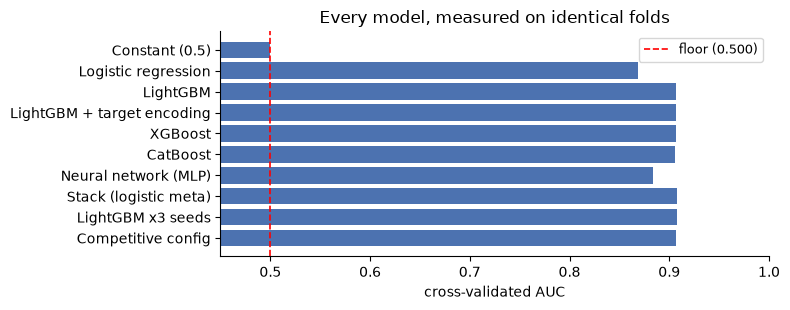

In [28]:
board = pd.DataFrame(scoreboard)
board["gain_vs_floor"] = board["cv_auc"] - 0.5
board = board[["model", "cv_auc", "cv_std", "gain_vs_floor", "note"]]
display(board.style.format({"cv_auc": "{:.5f}", "cv_std": "{:.5f}",
                            "gain_vs_floor": "{:+.5f}"}, na_rep="—"))

best_row = board.loc[board["cv_auc"].idxmax()]
print(f"Best model: {best_row['model']}  (CV AUC {best_row['cv_auc']:.5f})")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(board["model"][::-1], board["cv_auc"][::-1], color="#4C72B0")
ax.axvline(0.5, color="red", ls="--", lw=1.2, label="floor (0.500)")
ax.set_xlim(0.45, 1.0)
ax.set_xlabel("cross-validated AUC")
ax.set_title("Every model, measured on identical folds")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**What this cell does and why it matters**

This is the honest summary of everything above, and the habit most worth stealing from this
notebook.

**Why the scoreboard is the point.** Notice what it makes possible: you can see at a glance
which steps actually paid off and by how much. That is what tells you where to spend your
remaining time. If logistic regression got you to 0.85 and LightGBM to 0.87, the jump to trees
was worth it. If the blend added 0.0003 while the fold standard deviation is 0.002, **the blend
did not really do anything** and you should not believe it.

**Always compare a gain against `cv_std`.** An improvement smaller than the fold-to-fold noise
is not an improvement, it is a coincidence you have chosen to believe. This single comparison
prevents an enormous amount of wasted effort.

**On CV versus the public leaderboard.** When you submit, your public leaderboard score will
differ from your CV score. That is expected — different data, different sample. The advice that
matters:

**Trust your cross-validation over the public leaderboard.** Your CV is computed on the full
training set across five folds. The public leaderboard is one score on a fraction of the test
data. It is a *noisier* measurement, and chasing it is how people overfit to the public split
and drop when the private scores are revealed.

The healthy pattern: use CV to decide what to build, and use the leaderboard only as a sanity
check that the two move in roughly the same direction. If CV improves and the leaderboard
worsens repeatedly, something is genuinely wrong — most likely a train/test distribution
difference — and that is worth investigating rather than ignoring.

## 28b. What score should you actually expect?

A number without context is not information, so here is the real competitive landscape as of
mid-August 2026, taken from the public leaderboard of 2,273 teams:

| Position | Public AUC |
|---|---|
| 1st | 0.97134 |
| 10th | 0.97122 |
| 100th | 0.97113 |
| 500th | 0.96979 |
| Median | 0.96553 |

**Read the gaps, because they are the whole story:**

- 1st to 10th: **0.00012**
- 1st to 100th: **0.00021**
- 1st to median: **0.00581**

The top 100 teams are packed inside two ten-thousandths of AUC. **This competition is
saturated.** Independent analysis on the forum estimates the theoretical ceiling for this
label-generating process at roughly 0.9701 on the out-of-fold scale, against public stacks
already sitting at 0.9701 — meaning the remaining *real* signal is smaller than the gap between
1st and 20th place. Most of the ordering at the top is noise on the public split.

**What this means for you as a learner — and it is genuinely good news:**

1. **A straightforward, well-built pipeline like this one lands you in a respectable position.**
   The distance from a competent baseline to the leader is under 0.006 AUC.
2. **Grinding for the last 0.0001 teaches you very little.** It is measurement noise, not
   modelling skill. Two seeds of the same model swap dozens of leaderboard places.
3. **Understanding *why* each step helped is the durable skill.** It transfers to your next
   problem. A 0.0002 leaderboard climb does not.

**Expect your public leaderboard score to land roughly 0.001–0.0015 *above* your CV score.**
Competitors consistently report this offset, and nobody has reported a CV/leaderboard inversion —
adversarial validation on this data finds no meaningful distribution drift between train and
test. So your CV is trustworthy here. **Select your final submission by CV, not by public rank.**

## 29. Creating the submission file

In [29]:
candidates = {
    "logistic_regression": (lr_mean, test_lr),
    "lightgbm": (lgb_mean, test_lgb),
    "xgboost": (xgb_mean, test_xgb),
    "catboost": (cb_mean, test_cb),
    "neural_net": (nn_mean, test_nn),
    "lightgbm_te": (te_mean, test_te),
    "lgbm_seed_avg": (sa_mean, test_seedavg),
    "competitive": (comp_mean, test_comp),
    "stack": (stack_mean, test_stack),
}
best_name = max(candidates, key=lambda k: candidates[k][0])
best_score, best_test_pred = candidates[best_name]

print(f"Selected model: {best_name}  (CV AUC {best_score:.5f})\n")

submission = pd.DataFrame({
    ID_COL: test[ID_COL].values,
    TARGET: best_test_pred,
})

# ---------------------------- sanity checks ----------------------------
checks = {
    "row count matches sample_submission": len(submission) == len(sample_submission),
    "columns match sample_submission":     list(submission.columns) == list(sample_submission.columns),
    "ids match test set exactly":          submission[ID_COL].equals(test[ID_COL]),
    "no missing predictions":              submission[TARGET].notna().all(),
    "predictions within [0, 1]":           submission[TARGET].between(0, 1).all(),
    "predictions are not constant":        submission[TARGET].nunique() > 1,
    "no duplicate ids":                    not submission[ID_COL].duplicated().any(),
}
print("Submission sanity checks")
print("-" * 46)
for label, passed in checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}]  {label}")

if not all(checks.values()):
    raise ValueError("Submission failed validation — do not upload this file.")

submission.to_csv("submission.csv", index=False)
print(f"\nWrote submission.csv  ({len(submission):,} rows)")
display(submission.head())
print(submission[TARGET].describe())

Selected model: stack  (CV AUC 0.90813)

Submission sanity checks
----------------------------------------------
  [PASS]  row count matches sample_submission
  [PASS]  columns match sample_submission
  [PASS]  ids match test set exactly
  [PASS]  no missing predictions
  [PASS]  predictions within [0, 1]
  [PASS]  predictions are not constant
  [PASS]  no duplicate ids

Wrote submission.csv  (5,000 rows)


,id,addicted_label
0,12000,0.472084
1,12001,0.479137
2,12002,0.987327
3,12003,0.099116
4,12004,0.698434


count    5000.000000
mean        0.648450
std         0.340896
min         0.051447
25%         0.345982
50%         0.746291
75%         0.967644
max         0.995833
Name: addicted_label, dtype: float64


**What this cell does and why it matters**

**Model selection is automatic, by CV score.** We do not hand-pick a favourite; whichever model
scored best on cross-validation is the one that gets submitted. This removes a subtle bias —
people tend to submit the model they found most interesting to build rather than the one that
performs best.

**Why the sanity checks are not paranoia.** Every check above corresponds to a real, common way
people waste a submission:

| Check | The failure it catches |
|---|---|
| Row count | Dropped rows during processing — a very common merge bug |
| Column names | Kaggle rejects the file outright, sometimes cryptically |
| IDs match test | **Predictions silently misaligned with rows** — the worst one |
| No missing | `NaN` in the file causes rejection |
| Within [0, 1] | Raw model scores submitted instead of probabilities |
| Not constant | A bug produced one value everywhere; would score exactly 0.5 |
| No duplicate ids | A merge accidentally duplicated rows |

**The ID alignment check deserves emphasis.** If your predictions get reordered relative to the
test rows — easy to do with a stray `sort_values`, `groupby`, or `merge` — the file is
*perfectly valid* and *completely wrong*. It uploads fine, and it scores about 0.5. Every one of
these checks is cheap; a wasted submission on a deadline is not.

**Recall from Section 10 that we submit probabilities, not labels.** The `predictions within
[0,1]` and `not constant` checks are guarding exactly that. If you find yourself about to write
`.astype(int)` anywhere near this file, stop.

**To submit:** if you are running this inside a Kaggle notebook, commit the notebook and
`submission.csv` appears under the Output tab, ready to submit to the competition. Locally,
upload the file on the competition's Submit Predictions page. **The deadline is 31 August 2026,
23:59 UTC**, and you may submit multiple times per day — so submit early, verify the pipeline
works end to end, and improve from there.

## 30. Where to go next

The pipeline above is complete and honest, but it is deliberately a *foundation* rather than a
maximally-tuned solution. Here is what to try next, **ordered by expected return on effort**.

Sections 17 through 26 already implement the highest-value items: capacity tuning, generator-artifact
features, target encoding, three extra model families, stacking, and seed averaging. **Two of those
were measured and rejected** — which is itself the most useful thing this notebook can show you.

Here is what remains genuinely untried, in order of expected return.

### 1. Grow the stacking pool

The single biggest remaining lever on this competition. Public stacks reach the top ~50 by
combining **80–130 base models**, and competitors publish their OOF arrays on the shared
`StratifiedKFold(5, shuffle=True, random_state=42)` convention specifically so they can be pooled.
Measured effect of growing a pool from 79 to 132 members: **+0.00032** — against **±0.000004** for
tuning the meta-model's regularisation. **Adding base models beats tuning the blender**, and it is
not close.

### 2. Better tabular neural networks

Our `MLPClassifier` is deliberately simple. **RealMLP** and **TabM** are the competitive options,
and in the most recent comparable Playground episode they *beat* CatBoost and XGBoost on CV,
public and private score. Since the neural net is already the most decorrelated member of our
ensemble, making it stronger raises its stack weight directly — the two-dimensional entry
condition from Section 24 with both dimensions improved at once.

### 3. Optuna hyperparameter search

Replace the single-axis `num_leaves` sweep with a proper multi-dimensional search over
`num_leaves`, `min_child_samples`, `learning_rate`, `feature_fraction`, `reg_lambda`, and
especially **`max_bin`** — raising `max_bin` well above its default is reported as worth about
**+0.002** here. Use a subsample for the search, then confirm on full data.

### 4. Nested cross-validation for the stack

Section 25 flagged a residual optimism: the meta-model's training rows carry OOF predictions from
base models that saw some validation rows. Nested CV removes it. Expensive, and mainly worth doing
when you need to trust the absolute number rather than the ranking.

### 5. Adversarial validation

Train a classifier to distinguish train rows from test rows. On this data it scores ~0.50 once
missingness is imputed away, confirming no distribution drift — which is *why* CV is trustworthy
here. Worth running on any new competition before you trust your validation at all.

### What NOT to bother with

Worth stating explicitly, because these are the obvious things to try and they have been measured:

- **Do not add the original real-world dataset as extra training rows.** This is the standard
  Playground trick and here it **actively hurts** (about −0.0001 to −0.005 depending on weighting).
  The generator manufactured its own structure and repaired inconsistencies present in the source
  survey, so real-world rows are off-distribution. (The linked source dataset has also been removed
  from Kaggle.)
- **Do not add missing-indicator flags for numeric columns.** Zero gain — LightGBM already routes
  `NaN` natively — and they leak train/test split identity.
- **Do not over-tune the meta-model.** Sweeping the stacker's regularisation across two orders of
  magnitude moved the score by ±0.000004. Adding another base model beats tuning the blender.
- **Do not calibrate probabilities.** Section 10: it cannot change AUC.

---

## What to take away from this notebook

Above the specific techniques, five habits generalise to every ML problem you will meet:

1. **Understand the metric before optimising it.** ROC AUC measures ranking, which meant
   probabilities not labels, and made calibration irrelevant. Every metric has consequences
   like these.
2. **Establish a floor, then measure everything against it.** A score without a baseline is
   not information.
3. **Prevent leakage structurally, not by being careful.** Put preprocessing in a `Pipeline`
   and the entire class of bug becomes impossible.
4. **Compare every gain to your noise level.** An improvement smaller than `cv_std` is not an
   improvement.
5. **Start simple and make complexity earn its place.** Logistic regression before boosting,
   one model before an ensemble. If the complicated thing cannot beat the simple thing, the
   simple thing wins.

Good luck — and remember that a submission you understand is worth more than a higher score you
copied.